# Análisis de éxito en juegos hasta el 2016 

La tienda online Ice vende videojuegos por todo el mundo y está planeando una campaña publicitaria para el 2017. Este análisis se basa en datos históricos sobre las ventas de juegos hasta diciembre 2016. 

El propósito de este análisis es identificar patrones que determinen si un juego tiene éxito o no para detectar proyectos prometedores y tener una planificación eficiente de campañas publicitarias.

## Inicialización y vista general

In [1]:
# Cargar todas las librerías
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from scipy import stats as st
from scipy.stats import pearsonr

In [ ]:
# Cargar el archivo de datos en un DataFrame
#df = pd.read_csv("/datasets/games.csv")
df = pd.read_csv("../games.csv")

In [3]:
#Vista previa del DataFrame
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


El dataset contiene los siguientes datos:
- `Name` (Nombre)
- `Platform` (Plataforma)
- `Year_of_Release` (Año de lanzamiento)
- `Genre` (Género)
- `NA_sales` (ventas en Norteamérica en millones de dólares estadounidenses)
- `EU_sales` (ventas en Europa en millones de dólares estadounidenses)
- `JP_sales` (ventas en Japón en millones de dólares estadounidenses)
- `Other_sales` (ventas en otros países en millones de dólares estadounidenses)
- `Critic_Score` (máximo de 100)
- `User_Score` (máximo de 10)
- `Clasificación` (ESRB)

In [4]:
#información general/resumida sobre el DataFrame
total_rows = 16715
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


La vista previa muestra que:
- las columnas `Name`, `Year_of_Release`, `Genre`, `Critic_Score`, `User_Score` y `Rating` tienen valores ausentes
- la columna `Year_of_Release` es tipo float y deberia ser int ya que no hay decimales en los años
- la columna `User_Score` es tipo object y deberia ser float ya que esta columna representa calificaciones númericas

## Preprocesamiento de datos

A continuación, se hacen las correcciónes anteriormente detectadas:
- estandarizar los nombres de las columnas poniendolos todos en minúsculas
- cambiar el tipo de dato de las columnas `Year_of_Release` y `User_Score`
- investigar los valores ausentes y establecer valores representativos

Asimismo, se crea una columna con la suma de las ventas en todas las regiones para cada juego.

### Corregir nombres de columnas

In [6]:
#Cambiar los nombres de las columnas a minúsculas
df.columns = df.columns.str.lower()

### Buscar y corregir datos duplicados

Se analizan las columnas `name`, `platform` y `genre` en busca de valores duplicados.

In [7]:
#Se buscan valores duplicados en la columna name
df['name'].sort_values().unique()

array([' Beyblade Burst', ' Fire Emblem Fates', " Frozen: Olaf's Quest",
       ..., 'wwe Smackdown vs. Raw 2006', '¡Shin Chan Flipa en colores!',
       nan], dtype=object)

In [8]:
#Se buscan valores duplicados en la columna platform
df['platform'].sort_values().unique()

array(['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG',
       'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP',
       'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360',
       'XB', 'XOne'], dtype=object)

In [9]:
#Se buscan valores duplicados en la columna genre
df['genre'].sort_values().unique()

array(['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle',
       'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports',
       'Strategy', nan], dtype=object)

In [10]:
#Se buscan valores duplicados en la columna rating
df['rating'].sort_values().unique()

array(['AO', 'E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', nan], dtype=object)

No se encontraron valores extraños ni duplicados

### Corregir valores ausentes
Se investigan las siguientes columnas pues tienen valores ausentes:

 `name`, `year_of_release`, `genre`, `critic_score`, `user_Score` y `rating`

#### Valores ausentes en columna name y genre

In [11]:
#Investigar valores ausentes de columna name
df.query('name.isna() == True')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Los valores ausentes en la columna `name` coinciden con los de la columna `genre`.

In [12]:
print('Porcentaje de valores ausentes en la columna "name" y "genre":', round(2/total_rows*100,3),'%')

Porcentaje de valores ausentes en la columna "name" y "genre": 0.012 %


In [13]:
#Eliminar filas de valores ausentes en las columnas name y genre
df = df.query('name.isna() == False')

Los valores ausentes en las columnas `name` y `genre` son mínimos y tienen información incompleta en las demás columnas por lo que se eliminan.

#### Valores ausentes en columna year_of_release

In [14]:
#Investigar valores ausentes de columna year_of_release
df.query('year_of_release.isna() == True')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [15]:
print('Porcentaje de valores ausentes en la columna "year_of_release":', round(269/total_rows*100,2),'%')

Porcentaje de valores ausentes en la columna "year_of_release": 1.61 %


In [16]:
#Eliminar filas de valores ausentes en la columna year_of_release
df = df.query('year_of_release.isna() == False')

En ciertas filas, el nombre del juego incluye el año de lanzamiento del juego; sin embargo, las filas con este dato ausente son mínimas y no afectan el análisis por lo que se pueden eliminar.

#### Valores ausentes en columna critic_score

In [17]:
#Investigar valores ausentes de columna critic_score
df.query('critic_score.isna() == True')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [18]:
df['critic_score'].describe()

count    7983.000000
mean       68.994363
std        13.920060
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: critic_score, dtype: float64

In [19]:
print('Porcentaje de valores ausentes en la columna "critic_score":', round(8461/total_rows*100,2),'%')

Porcentaje de valores ausentes en la columna "critic_score": 50.62 %


In [20]:
#Asignar el valor NAN a los valores ausentes para continuar el análisis sin errores por tipo de dato
df['critic_score'] = df['critic_score'].fillna(np.nan)

Las filas con valores ausentes en la columna `critic_score` representan más de la mitad de los datos de esta columna por lo que no se pueden eliminar y tampoco se tiene suficiente información para establecer un valor representativo sin alterar el análisis. 

Se continua asumiendo falta de datos en esta columna.

#### Valores ausentes en columna user_score

In [21]:
#Investigar valores ausentes de columna user_score
df.query('user_score.isna() == True')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [22]:
print('Porcentaje de valores ausentes en la columna "user_score":', round(6605/total_rows*100,2),'%')

Porcentaje de valores ausentes en la columna "user_score": 39.52 %


Las filas con valores ausentes en la columna `user_score` representan un porcentaje alto por lo que no se pueden eliminar y tampoco se tiene suficiente información para establecer un valor representativo sin alterar el análisis.

Se continua asumiendo falta de datos en esta columna.

In [23]:
#Asignar el valor NAN a los valores ausentes para continuar el análisis sin errores por tipo de dato
df['user_score'] = df['user_score'].fillna(np.nan)

#### Valores ausentes en columna rating

In [24]:
#Se buscan valores duplicados en la columna rating
df['rating'].sort_values().unique()

array(['AO', 'E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', nan], dtype=object)

La columna rating cuenta con los siquientes valores:
- E (todos)
- EC (mayores de 3 años) dejó de usarse en 2018 y se reemplazó con E
- E10+ (mayores de 10 años)
- K-A (mayores de 10 años) dejó de usarse en 1998 y se reemplazó con E10+
- T (mayores de 13 años)
- M (mayores de 17 años)
- A0 (sólo para adultos de 18 años en adelante)
- RP (pendiente de clasificar)

In [25]:
#Investigar valores ausentes de columna rating
df.query('rating.isna() == True')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [26]:
#Investigar valores ausentes de columna rating
df.query('rating.isna() == True and year_of_release < 1994')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
18,Super Mario World,SNES,1990.0,Platform,12.78,3.75,3.54,0.55,NaN,NaN,NaN
21,Super Mario Land,GB,1989.0,Platform,10.83,2.71,4.18,0.42,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13343,Beyond Oasis,GEN,1993.0,Role-Playing,0.00,0.00,0.05,0.00,NaN,NaN,NaN
13571,Sonic the Hedgehog 2 (8-bit),GG,1992.0,Platform,0.00,0.00,0.04,0.00,NaN,NaN,NaN
15692,Empire Deluxe,PC,1992.0,Strategy,0.02,0.00,0.00,0.00,NaN,NaN,NaN
15957,Strongest Tokyo University Shogi DS,DS,1985.0,Action,0.00,0.00,0.02,0.00,NaN,NaN,NaN


La ESRB se fundo en 1994, por lo que es comprensible que haya múltiples juegos lanzados en años anteriores sin esta clasificación.

In [27]:
print('Porcentaje de valores ausentes en la columna "rating":', round(6676/total_rows*100,2),'%')

Porcentaje de valores ausentes en la columna "rating": 39.94 %


Las filas con valores ausentes en la columna `rating` representan un porcentaje alto por lo que no se pueden eliminar. A continuación se busca un valor representativo para ellas.

In [28]:
df['rating'].value_counts()

rating
E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
AO         1
RP         1
Name: count, dtype: int64

Se establecen los valores ausentes de la columna `rating` como `RP`, es decir, pendiente de clasificar (Rating Pending)

In [29]:
#Asignar el valor unknown a los valores ausentes
df['rating'] = df['rating'].fillna("RP")

### Corregir tipos de datos

In [30]:
#Cambiar tipo de dato
df['year_of_release'] = df['year_of_release'].astype('int')

In [31]:
#Investigar tipo de dato de columna user_score
df.query('user_score == "tbd"').head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
718,Just Dance Kids,Wii,2010,Misc,1.52,0.54,0.0,0.18,NaN,tbd,E


El valor `tbd`(to be defined) en la columna `user_score` probablemente se deba a calificaciones de usuarios insuficientes, por lo que este valor se mantiene así y la columna permanece con el tipo de dato de objeto.

### Enriquecer datos

Se crea una columna con las ventas totales de cada videojuego. 

In [32]:
#Crear columna de ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

Se crea una columna con las ventas totales promedio por año

In [33]:
df['sales_per_year'] = round( df['total_sales'] /  (2017-df['year_of_release'])  ,2)

### Verificar cambios

In [34]:
#Ver cambios
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,sales_per_year
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54,7.50
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,RP,40.24,1.26
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,3.95
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77,4.10
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,RP,31.38,1.49


In [35]:
#verificar informacion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int32  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           16444 non-null  object 
 11  total_sales      16444 non-null  float64
 12  sales_per_year   16444 non-null  float64
dtypes: float64(7), int32(1), object(5)
memory usage: 1.7+ MB


## Analizar datos
A continuación, se examinan los datos limpios en busca de proyectos prometedores.

### Ventas por año de lanzamiento
Se observan los juegos agrupados por año de lanzamiento para ver si este factor es significativo.

In [36]:
#Juegos lanzados por año
df.groupby('year_of_release')['name'].count()

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64

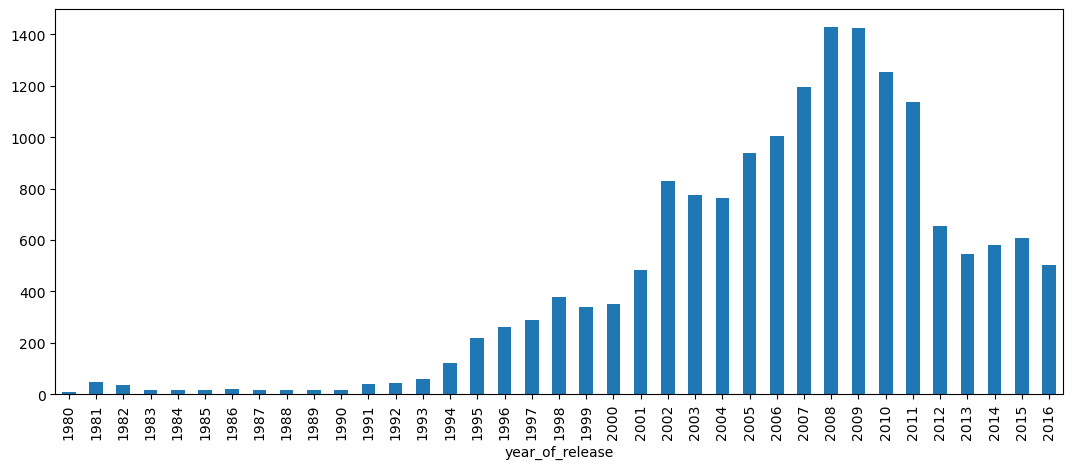

In [37]:
#Juegos lanzados por año
df.groupby('year_of_release')['name'].count().plot(kind='bar',figsize=(13,5))
plt.show()

Los años con más juegos lanzados fueron los años entre 2005 y 2011. Incluso, cada uno de ellos duplica la cantidad de juegos lanzados en el 2016.

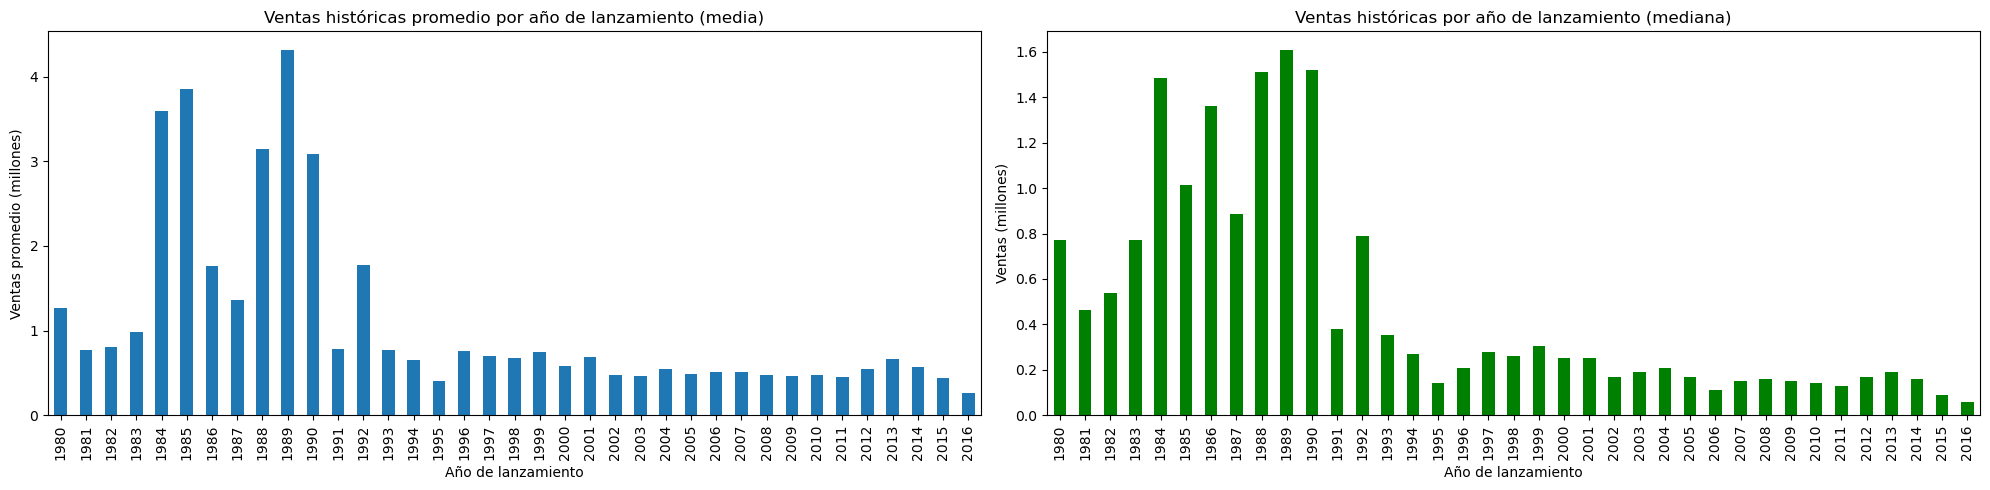

In [38]:
#importante: no se ven subplots en el curso
#Ingresos históricos de juegos por año de lanzamiento
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Media de ventas históricas por año de lanzamiento - azul
df.groupby('year_of_release')['total_sales'].mean().plot( kind='bar', ax=axes[0])
axes[0].set_title('Ventas históricas promedio por año de lanzamiento (media)')
axes[0].set_xlabel('Año de lanzamiento')
axes[0].set_ylabel('Ventas promedio (millones)')

# Mediana de ventas históricas por año de lanzamiento - verde
df.groupby('year_of_release')['total_sales'].median().plot( kind='bar', ax=axes[1], color='green')
axes[1].set_title('Ventas históricas por año de lanzamiento (mediana)')
axes[1].set_xlabel('Año de lanzamiento')
axes[1].set_ylabel('Ventas (millones)')

plt.tight_layout()
plt.show()


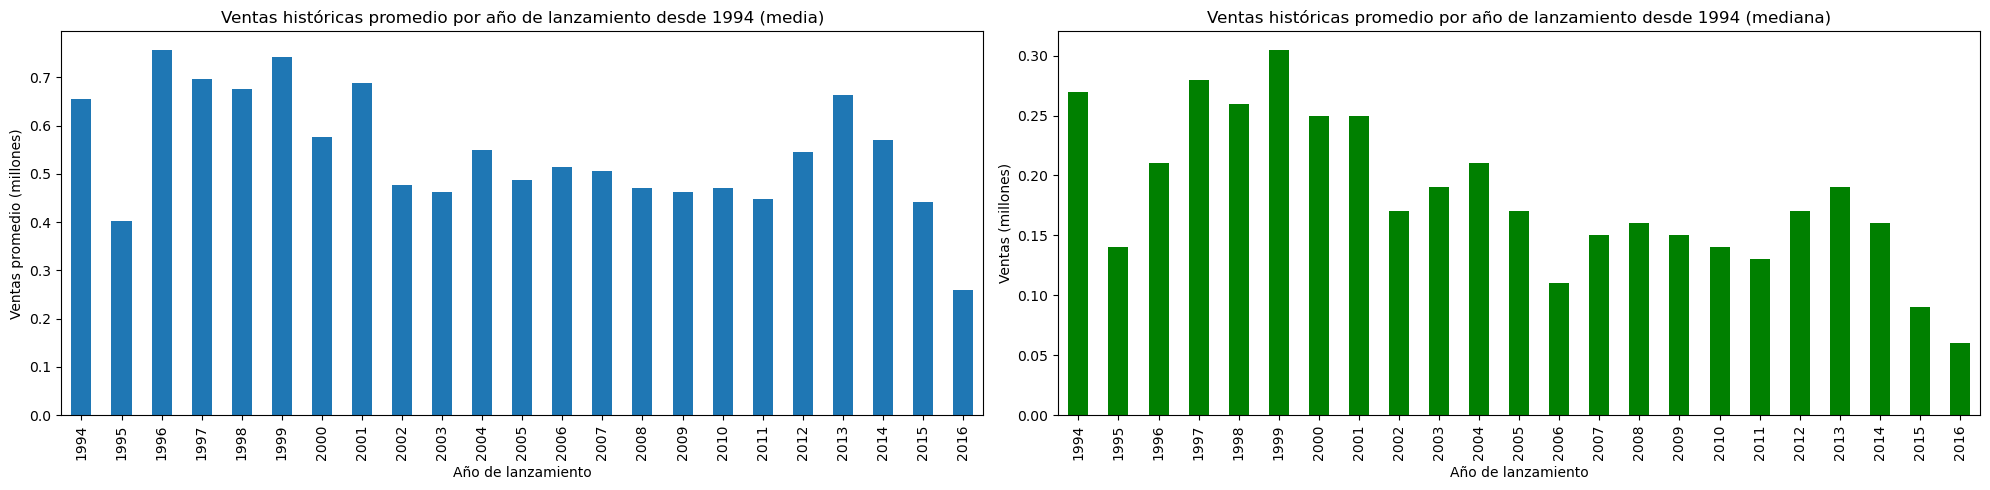

In [39]:
#importante: no se ven subplots en el curso
#Ingresos históricos de juegos por año de lanzamiento después de 1993
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Media ventas después de 1993 - azul
df.query('year_of_release > 1993').groupby('year_of_release')['total_sales'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Ventas históricas promedio por año de lanzamiento desde 1994 (media)')
axes[0].set_xlabel('Año de lanzamiento')
axes[0].set_ylabel('Ventas promedio (millones)')

# Mediana ventas después de 1993 - verde
df.query('year_of_release > 1993').groupby('year_of_release')['total_sales'].median().plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Ventas históricas promedio por año de lanzamiento desde 1994 (mediana)')
axes[1].set_xlabel('Año de lanzamiento')
axes[1].set_ylabel('Ventas (millones)')

plt.tight_layout()
plt.show()


In [40]:
df.query('2005<= year_of_release <=2011').groupby('year_of_release')['total_sales'].mean()

year_of_release
2005    0.487561
2006    0.514622
2007    0.505221
2008    0.470568
2009    0.462006
2010    0.470223
2011    0.446813
Name: total_sales, dtype: float64

Pocos juegos, menos de 60, se lanzaron cada año en los años anteriores a 1994. Al haber poca disponibilidad de juegos, el ingreso histórico de ventas por juego incrementa. A partir del 1994, los juegos lanzados por año fueron incrementando cosa que disminuyo los ingresos por juego, al haber máyor variedad de juegos, el gasto que la gente hace se reparte en distintos juegos.

Los promedios de ingresos históricos de los juegos lanzados a partir del año 1994, se mantienen entre 0.2 y 0.7 MDD, a diferencia de los juegos lanzados años anteriores que alcanzaban promedios historicos de hasta 4 MDD. Adicionalmente, entre 
2005 y 2011, los años con mayor cantidad de juegos lanzados, los promedios de ingresos por año de lanzamiento, oscilan entre 0.44 y 0.51 MDD. Estos promedios suben en los años siguientes cuando la cantidad de juegos lanzados disminuye.

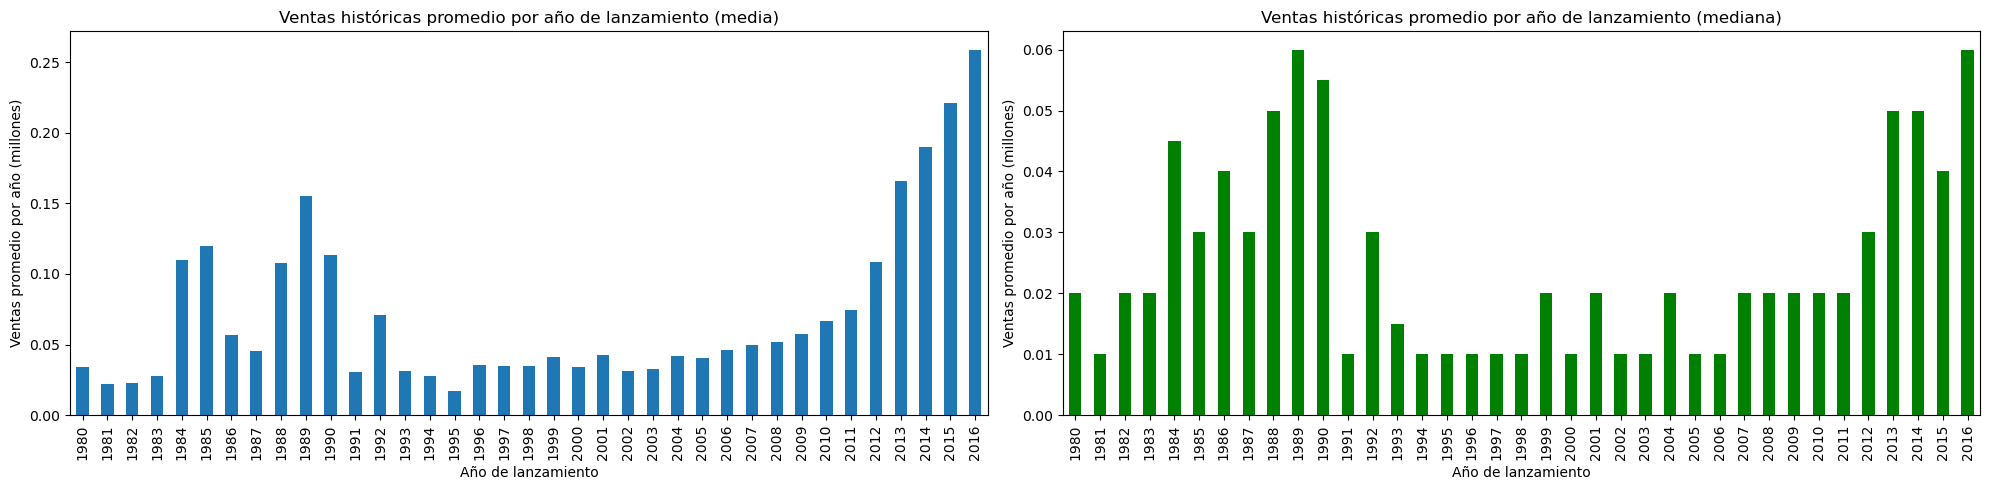

In [41]:
#importante: no se ven subplots en el curso
#Ingresos anuales de juegos por año de lanzamiento
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Media ventas históricas por año - azul
df.groupby('year_of_release')['sales_per_year'].mean().plot( kind='bar', ax=axes[0])
axes[0].set_title('Ventas históricas promedio por año de lanzamiento (media)')
axes[0].set_xlabel('Año de lanzamiento')
axes[0].set_ylabel('Ventas promedio por año (millones)')

# Mediana ventas históricas por año - verde
df.groupby('year_of_release')['sales_per_year'].median().plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Ventas históricas promedio por año de lanzamiento (mediana)')
axes[1].set_xlabel('Año de lanzamiento')
axes[1].set_ylabel('Ventas promedio por año (millones)')

plt.tight_layout()
plt.show()


In [42]:
#Mediana del año 1989 y 2016
df.query('year_of_release ==1989 or  year_of_release == 2016').groupby('year_of_release')['sales_per_year'].median()

year_of_release
1989    0.06
2016    0.06
Name: sales_per_year, dtype: float64

In [43]:
print('Historical sales per year of release')
df.query('year_of_release ==1989 or  year_of_release == 2016').groupby('year_of_release')['total_sales'].describe()

Historical sales per year of release


,count,mean,std,min,25%,50%,75%,max
year_of_release,,,,,,,,
1989,17.0,4.320588,7.895161,0.06,1.10,1.61,2.12,30.26
2016,502.0,0.258845,0.698041,0.01,0.02,0.06,0.20,7.60


Al examinar las medianas de los ingresos anuales de los juegos lanzados antes de 1994, son parecidos a los de los juegos lanzados después del 2011. Incluso, la mediana de 1989 es la misma que la de 2016, pero al analizar los demás estadísticos, se sabe que de los 17 juegos lanzados ese año, el ingreso máximo fue de 30.26 MDD mientras que en el 2016, de 502 juegos, el ingreso máximo de ellos fue de 7.6 MDD, cosa que reafirma que al haber más variedad de juegos, los ingresos se reparten y los promedios por juego disminuyen.

### Ventas por plataforma
Se observan como varían las ventas entre plataformas

In [44]:
#número de ventas por plataforma
df.groupby('platform')['total_sales'].count().sort_values(ascending=False).head(10)

platform
PS2     2127
DS      2121
PS3     1306
Wii     1286
X360    1232
PSP     1193
PS      1190
PC       957
GBA      811
XB       803
Name: total_sales, dtype: int64

In [45]:
#ingresos de ventas totales por plataforma
df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

Las 5 plataformas con más juegos vendidos son: 
1. PS2
2. DS
3. PS3
4. Wii
5. X360   

Mientras que las 5 plataformas con más ingresos históricos son:
1. PS2
2. X360
3. PS3
4. Wii
5. DS

Las 5 primeras plataformas con estas características son las mismas pero en orden distinto por lo que se consideran plataformas potencialmente rentables.

In [46]:
#Ganancias aproximadas por juego
(df.groupby('platform')['total_sales'].sum()/df.groupby('platform')['total_sales'].count()).sort_values(ascending=False).head(10)

platform
GB      2.622990
NES     2.561735
GEN     1.050000
SNES    0.836987
PS4     0.801378
X360    0.780227
2600    0.745517
PS3     0.713124
Wii     0.692986
N64     0.689905
Name: total_sales, dtype: float64

In [47]:
for plat in ['GB','NES','GEN','SNES','PS4']:
    print(plat,df.query('platform == @plat')['year_of_release'].min())

GB 1988
NES 1983
GEN 1990
SNES 1990
PS4 2013


Las plataformas con más ingresos por juego son:
1. GB
2. NES
3. GEN
4. SNES
5. PS4

Las primeras 4 no se encuentran en los dos primeros grupos y se estrenaron antes del 2000, por lo que únicamente se considera relevante la plataforma PS4.

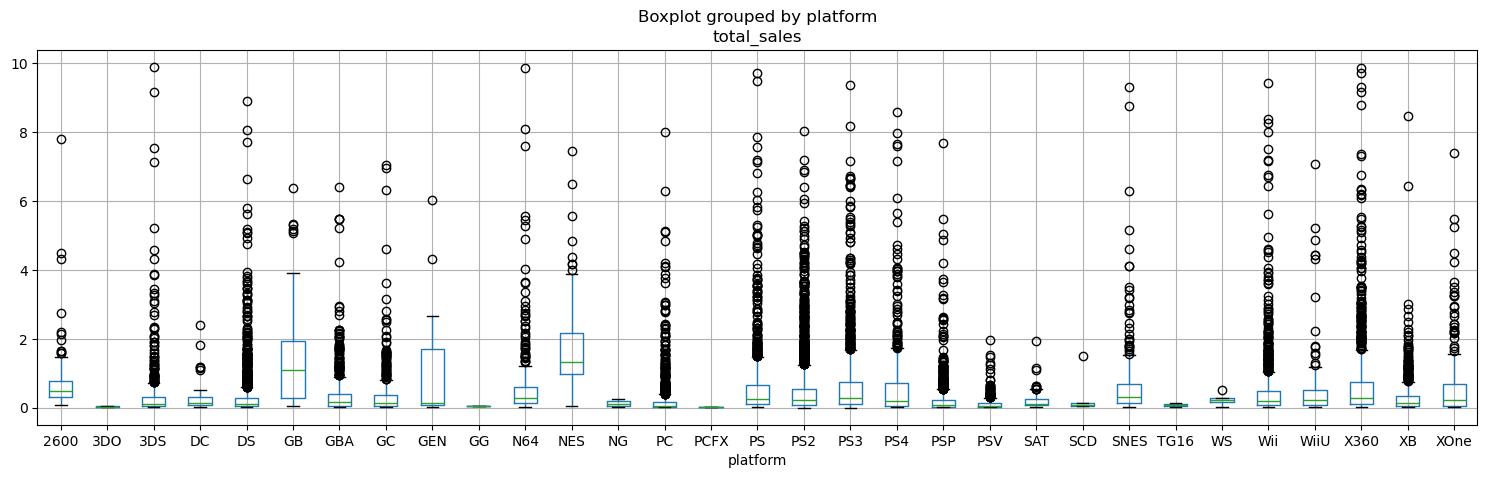

In [48]:
df.query('total_sales<10').boxplot(column='total_sales',by='platform',figsize=(18, 5))
plt.show()

Se examina el promedio y la mediana de ventas anuales por plataforma.

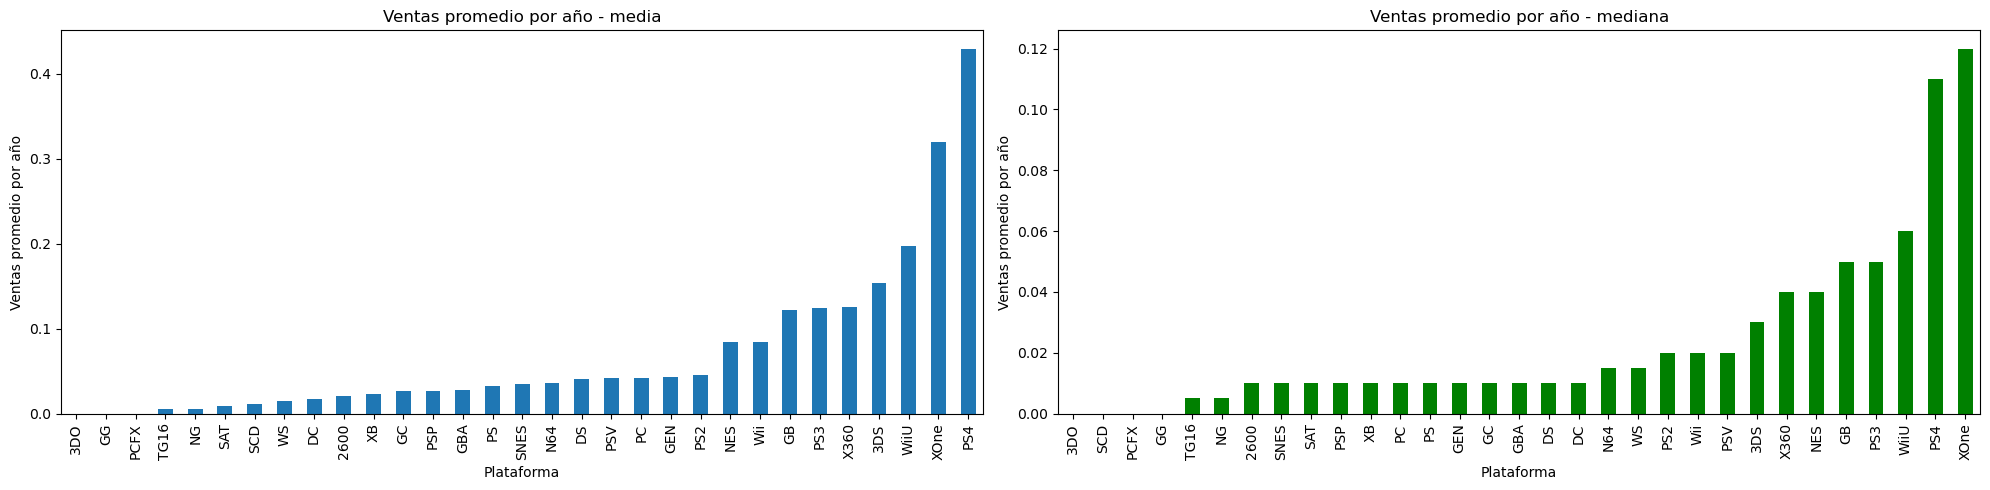

In [49]:
#importante: no se ven subplots en el curso
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Media de ventas por plataforma - azul
df.groupby('platform')['sales_per_year'].mean().sort_values().plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Ventas promedio por año - media')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Ventas promedio por año')

# Mediana de ventas por plataforma - verde
df.groupby('platform')['sales_per_year'].median().sort_values().plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Ventas promedio por año - mediana')
axes[1].set_xlabel('Plataforma')
axes[1].set_ylabel('Ventas promedio por año')

plt.tight_layout()
plt.show()


Al observar los ingresos anuales promedio, las plataformas PS4, XOne, WiiU, 3DS y X360 están en los promedios más altos. 

Al ver las medianas de esta misma característica, las plataformas XOne, PS4, WiiU, PS3 y GB tienen las medianas más altas.

Tomando en cuenta los datos anteriores, donde las plataformas con mayores ingresos históricos se encuentran a la mitad en los gráficos del promedio de ingreso anual, se puede afirmar que hay plataformas que en dado momento tuvieron mucho exito, como lo son PS2 y PS3, sin embargo actualmente son otras las que lideran el mercado y podrían estar en crecimiento.

### Tiempo de vida de plataformas

Enseguida se hará un análisis de cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer.

In [50]:
#Plataformas
df['platform'].sort_values().unique()

array(['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG',
       'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP',
       'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360',
       'XB', 'XOne'], dtype=object)

Se agrupan las plataformas por familias
- Atari: 2600
- Panasonic: 3D0
- Nintendo: 3DS, GC (game cube), N64, NES, SNES, Wii, WiiU
- Nintendo game boy: GB, GBA
- Nintendo: DS
- Sega: DC (Dreamcast), GEN (genesis), GG (game gear), SAT (saturn), SCD
- Sony: PS, PS2, PS3, PS4, PSP, PSV
- Microsoft: X360, XB, XOne
- NEC: PC, PCFX, TG16
- SNK: NG (consola Neo Geo)
- Bandai: WS (WonderSwan)

Se seleccionan grupos de consolas similares que actualmente tienen altos ingresos por año para este análisis que son:
- Wii y WiiU 
- X360, XB y XOne
- PS, PS2, PS3 y PS4

In [51]:
for plat in ['Wii','WiiU','XB','X360','XOne','PS','PS2','PS3','PS4']:
    print('year of release of the first game released in the platform',plat,':'
          ,df.query('platform == @plat')['year_of_release'].min())

year of release of the first game released in the platform Wii : 2006
year of release of the first game released in the platform WiiU : 2012
year of release of the first game released in the platform XB : 2000
year of release of the first game released in the platform X360 : 2005
year of release of the first game released in the platform XOne : 2013
year of release of the first game released in the platform PS : 1994
year of release of the first game released in the platform PS2 : 2000
year of release of the first game released in the platform PS3 : 2006
year of release of the first game released in the platform PS4 : 2013


Al analizar las consolas Wii y WiiU de Nintendo, hay 6 años entre ellas.

Al analizar las consolas XB, X360 y XOne de Microsoft, hay 5 años entre la primera y la segunda y 8 entre la segunda y la última.

Al analizar las consolas PS, PS2, PS3 y PS4 de Sony, hay 6 años entre la primera y la segunda, 6 entre la segunda y la tercera y 7 entre la tercera y la última.

In [52]:
years = [6,5,8,6,6,7]
print('En promedio, el tiempo de vida de las plataformas analizadas es de',round(sum(years)/len(years),2),'años')
print('La mediana del tiempo de vida de las plataformas analizadas es de 6 años')

En promedio, el tiempo de vida de las plataformas analizadas es de 6.33 años
La mediana del tiempo de vida de las plataformas analizadas es de 6 años


Tomando en cuenta el resultado anterior, se establece que en promedio, cada 6 años sale una nueva plataforma de cada familia.

A continuación, se analizan las ventas de juegos por plataforma y por año para complementar la información anterior.

Para este análisis, se seleccionan los mimsos grupos de consolas que tienen altos ingresos por año:
- Wii y WiiU 
- X360, XB y XOne
- PS, PS2, PS3 y PS4

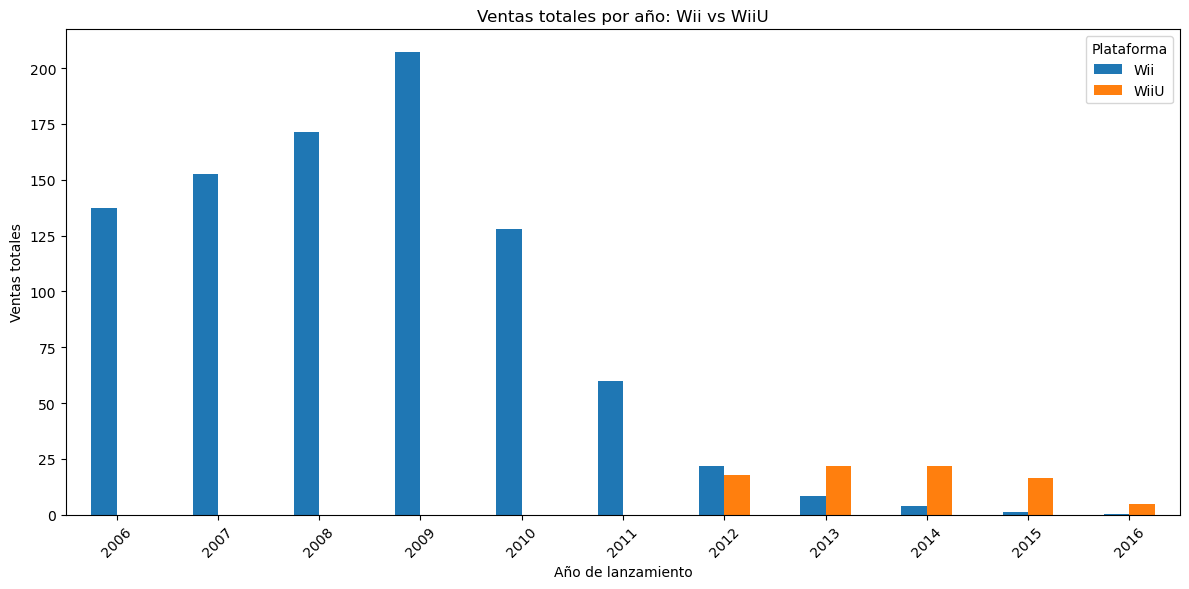

In [53]:
#Ventas por año de consolas Wii y WiiU

# Agrupar ventas por año para cada plataforma
wii_sales = df.query('platform == "Wii"').groupby('year_of_release')['total_sales'].sum()
wiiu_sales = df.query('platform == "WiiU"').groupby('year_of_release')['total_sales'].sum()

# Crear un DataFrame combinando ambas plataformas
sales_comparison = pd.DataFrame({ 'Wii': wii_sales, 'WiiU': wiiu_sales }).fillna(0)  # Completar años faltantes con 0 ventas

# Plot barras agrupadas
sales_comparison.plot(kind='bar', figsize=(12,6), title='Ventas totales por año: Wii vs WiiU')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


Los juegos lanzados años después de que salio la plataforma `Wii` son los de mayores ingresos en esta; sin embargo los ingresos de juegos lanzados 6 años después, en el 2012, decayeron considerablemente. Lo anterior mencionado podría deberse al lanzamiento de la plataforma `WiiU` que salió en el 2012, el mismo año mencionado. 

Los ingresos obtenidos con la plataforma `WiiU` han sido buenos pero no se acercan a los obtenidos con la otra plataforma.

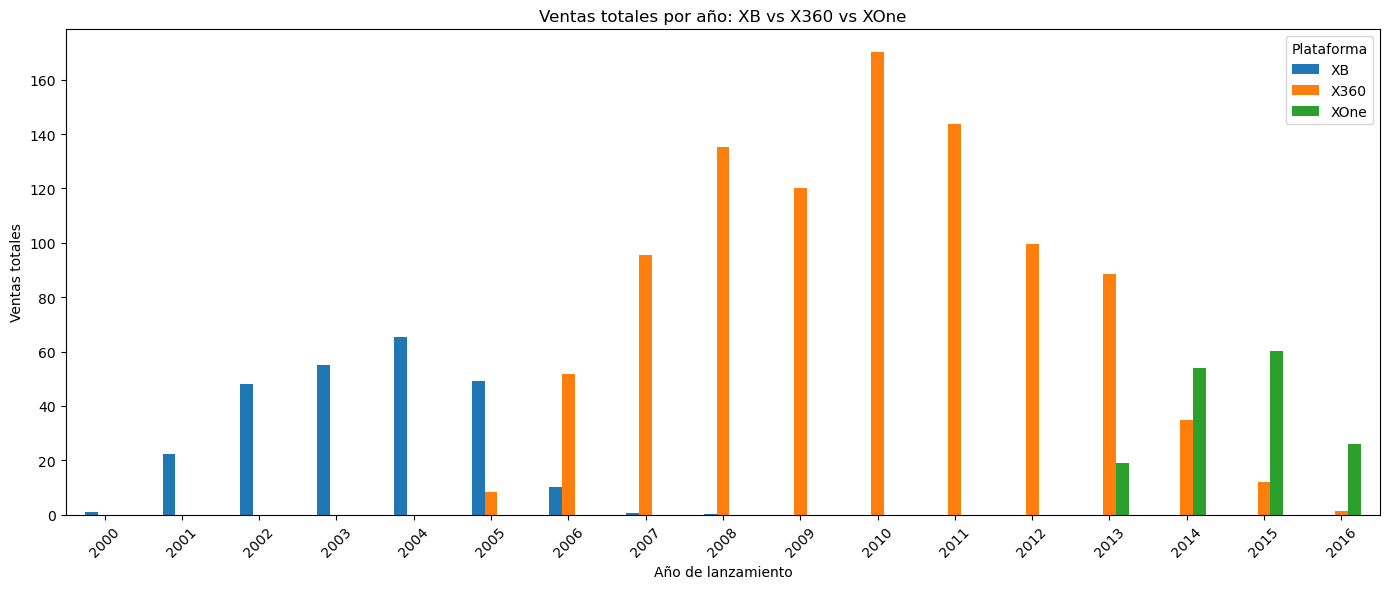

In [54]:
#Ventas por año de consolas X360,XB y XOne

# Agrupar ventas por año para cada plataforma
xb_sales = df.query('platform == "XB"').groupby('year_of_release')['total_sales'].sum()
x360_sales = df.query('platform == "X360"').groupby('year_of_release')['total_sales'].sum()
xone_sales = df.query('platform == "XOne"').groupby('year_of_release')['total_sales'].sum()

# Combinar en un solo DataFrame
sales_comparison = pd.DataFrame({ 'XB': xb_sales, 'X360': x360_sales, 'XOne': xone_sales }).fillna(0)

# Graficar barras agrupadas
sales_comparison.plot(kind='bar', figsize=(14,6))
plt.title('Ventas totales por año: XB vs X360 vs XOne')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


La plataforma `XB` confirma el por qué cada 6 años sale una nueva plataforma; pues los juegos lanzados 6 años desúes de que la plataforma salió, han tenido pocas ventas. Las mejores ventas de esta plataforma fueron de los juegos lanzados en el 2004, 4 años después del lanzamiento de la plataforma.

La plataforma `X360` tiene los ingresos mayores por juegos lanzados en el 2010 y 2011, juegos lanzados 5 y 6 años despúes de que salió la plataforma. A diferencia de la `XB`, la `X360` ha seguido teniendo ventas considerables por juegos lanzados varios años despúes del lanzamiento de la plataforma.

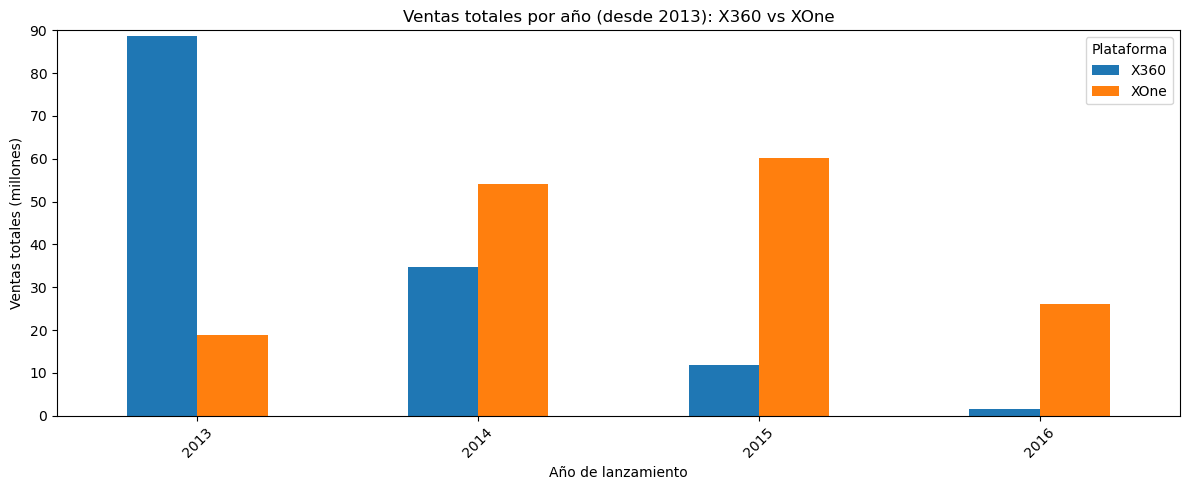

In [55]:
# Filtrar y agrupar ventas por año desde 2013 para X360 y XOne
x360_sales = df.query('platform == "X360" and year_of_release >= 2013').groupby('year_of_release')['total_sales'].sum()
xone_sales = df.query('platform == "XOne" and year_of_release >= 2013').groupby('year_of_release')['total_sales'].sum()

# Combinar los datos en un DataFrame
sales_comparison = pd.DataFrame({ 'X360': x360_sales, 'XOne': xone_sales }).fillna(0)

# Crear gráfica de barras agrupadas
sales_comparison.plot(kind='bar', figsize=(12, 5))
plt.title('Ventas totales por año (desde 2013): X360 vs XOne')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.ylim(0, 90)
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


Al comparar los años donde `X360` y `XOne` han estado presentes, la `X360` superá los ingresos de la `XOne` en los juegos lanzados en 2013; en los juegos lanzados los años siguientes la `XOne` sube sus ingresos pero no se acerca a los ingresos de la `X360` en sus mejores años.

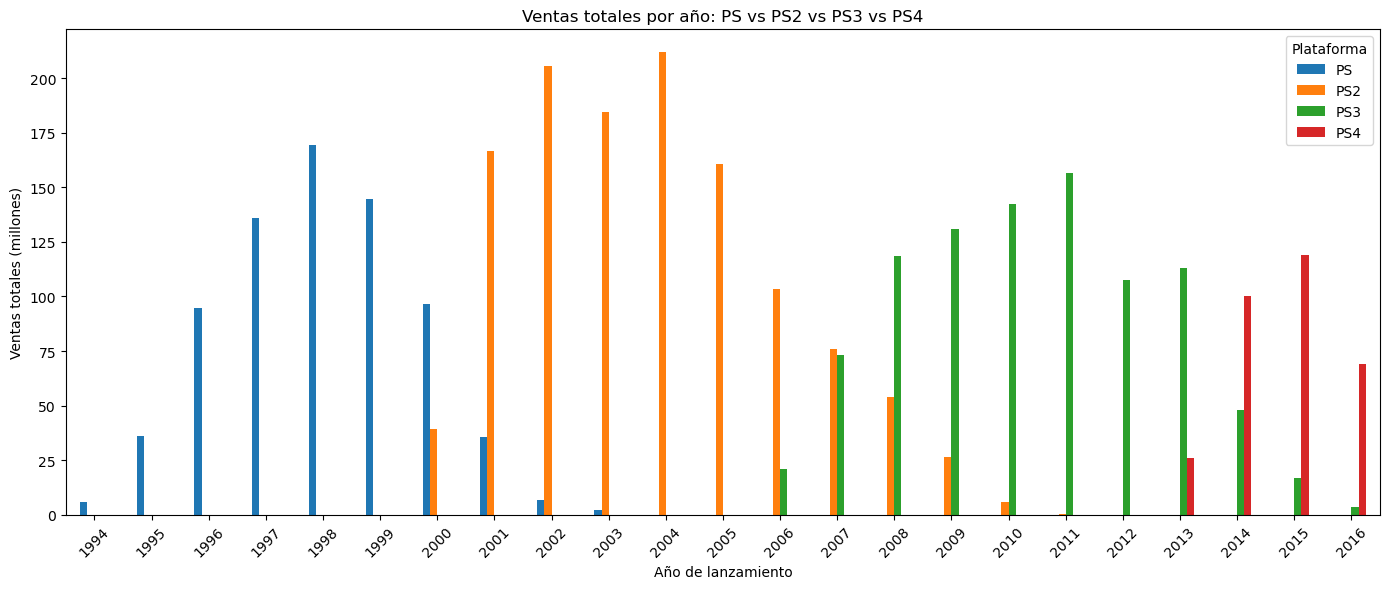

In [56]:
#Ventas por año de consolas PS, PS2, PS3 y PS4

# Agrupar ventas por año para cada consola
ps_sales = df.query('platform == "PS"').groupby('year_of_release')['total_sales'].sum()
ps2_sales = df.query('platform == "PS2"').groupby('year_of_release')['total_sales'].sum()
ps3_sales = df.query('platform == "PS3"').groupby('year_of_release')['total_sales'].sum()
ps4_sales = df.query('platform == "PS4"').groupby('year_of_release')['total_sales'].sum()

# Combinar los datos en un solo DataFrame
sales_comparison = pd.DataFrame({ 'PS': ps_sales, 'PS2': ps2_sales, 'PS3': ps3_sales, 'PS4': ps4_sales }).fillna(0)

# Gráfica de barras agrupadas
sales_comparison.plot(kind='bar', figsize=(14,6))
plt.title('Ventas totales por año: PS vs PS2 vs PS3 vs PS4')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


Al analizar los ingresos por año de lanzamiento de los juegos de la familia de `PSs`, se osberva que al salir una nueva plataforma, los ingresos de los juegos de la anterior van decayendo. 

El comportamiento de los ingresos de las plataformas de `PSs` son similares e incluso tienen parecidas cantidades de ingresos, a diferencia de otras plataformas donde la más reciente de cada familia no alcanza los altos ingresos de sus predecesoras. 

In [57]:
#Se investigan las plataformas que tienen menos de 6 años o menos de lanzamiento
print('Platforms were the first game released was in 2010 or after:')
for plat in ['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG','N64', 'NES', 'NG', 'PC', 'PCFX','PS'
        ,'PS2', 'PS3', 'PS4', 'PSP','PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360','XB', 'XOne']:
    if df.query('platform == @plat')['year_of_release'].min() >=2010:
        print (plat, '- First game released in',df.query('platform == @plat')['year_of_release'].min())

Platforms were the first game released was in 2010 or after:
3DS - First game released in 2011
PS4 - First game released in 2013
PSV - First game released in 2011
WiiU - First game released in 2012
XOne - First game released in 2013


Tomando en cuenta los análisis anteriores, se sabe que a partir de 1994, los ingresos se estabilizaron, por lo que no se toman como referencia los años anteriores. 

Asimismo, se estima que cada 6 años cambia el mercado tras el ingreso de nuevas plataformas, por lo que no se consideran relevantes los juegos con más de 6 años desde su lanzamiento. 

Tomando en cuenta los años de lanzamiento de las nuevas plataformas junto con la información anterior, se determina que los datos útiles para el modelo del 2017 son los juegos donde el año de lanzamiento fue el 2011, es decir juegos menores a 6 años.

In [58]:
df_recent_data = df.query('year_of_release >= 2011')

### Relación entre ventas y reseñas

#### Relación entre ventas y reseñas de todas las plataformas
Se analiza cómo las reseñas de usuarios y profesionales afectan las ventas en general.

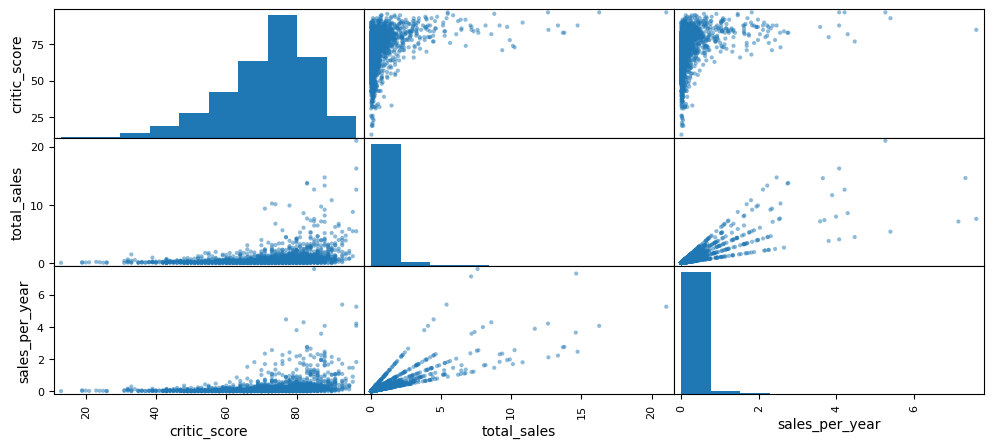

In [59]:
#Matriz de dispersión
df_no_tbd = df_recent_data.query('user_score!="tbd" ')
df_no_tbd.loc[:, 'user_score'] = df_no_tbd['user_score'].astype('float')
scat_matrix = pd.plotting.scatter_matrix(df_no_tbd.loc[:,['critic_score','user_score','total_sales','sales_per_year']]
            , figsize=(12, 5))

In [60]:
#Matriz de correlación: critic_score
df_recent_data.loc[:,['critic_score','total_sales','sales_per_year']].corr()

,critic_score,total_sales,sales_per_year
critic_score,1.000000,0.329977,0.313688
total_sales,0.329977,1.000000,0.835448
sales_per_year,0.313688,0.835448,1.000000


In [61]:
#Matriz de correlación: user_score
df_no_tbd.loc[:,['user_score','total_sales','sales_per_year']].corr()

,user_score,total_sales,sales_per_year
user_score,1.000000,0.031636,0.008173
total_sales,0.031636,1.000000,0.834297
sales_per_year,0.008173,0.834297,1.000000


La información anterior muestra que:
- La columna `critic_score` presenta una correlación positiva débil con la columna `total_sales`. Esto indica, que en general, a mayores calificaciones por parte de los críticos, mayores tienden a ser las ventas. Sin embargo, debe tomarse en cuenta que el 50.62 % de los valores de critic_score están ausentes.
- La columna `user_score` no muestra una correlación significativa con las ventas totales. No obstante, debido a que esta variable tiene un 39.52 % de valores ausentes, no es posible generalizar este resultado con certeza.

Para evaluar la relación entre las columnas `critic_score` y `total_sales`, se aplica una prueba de correlación de Pearson y se obtiene el valor p correspondiente.
- Hipótesis nula (H₀): No existe correlación lineal entre las calificaciones de los críticos (critic_score) y las ventas totales de los juegos (total_sales).
- Hipótesis alternativa (H₁): Existe una correlación lineal entre las calificaciones de los críticos y las ventas totales de los juegos.

Se establece un nivel de significancia de α = 0.05 (5%).

In [62]:
# Cálculo de correlación y significancia
r, p = st.pearsonr(df_no_tbd.query('critic_score.isna() == False')['critic_score'], df_no_tbd.query(
                                    'critic_score.isna() == False')['total_sales'])
r = round(r,3)
print(f"Correlación Pearson: coeficiente = {r}, p-value ={p}")

alpha=0.05
if p < alpha: print("Se rechaza la hipótesis nula") 
else: print("No se rechaza la hipótesis nula")  

Correlación Pearson: coeficiente = 0.327, p-value =2.769275511972679e-45
Se rechaza la hipótesis nula


El análisis proporciona evidencia estadísticamente significativa para afirmar que existe una correlación lineal entre las calificaciones de los críticos (`critic_score`) y las ventas totales de los juegos (`total_sales`).

Se obtuvo un coeficiente de correlación de Pearson de 0.327, lo cual indica una correlación positiva débil, pero significativa. Esto sugiere que, en general, a mayor calificación por parte de los críticos, mayores tienden a ser las ventas, aunque la relación no es fuerte.

Sin embargo, es importante tener en cuenta que la columna `critic_score` presenta un 50.62 % de valores ausentes, lo que limita la generalización de este resultado.

#### Relación entre ventas y reseñas de la plataforma X360
Se analiza cómo las reseñas de usuarios y profesionales afectan las ventas de la plataforma X360.

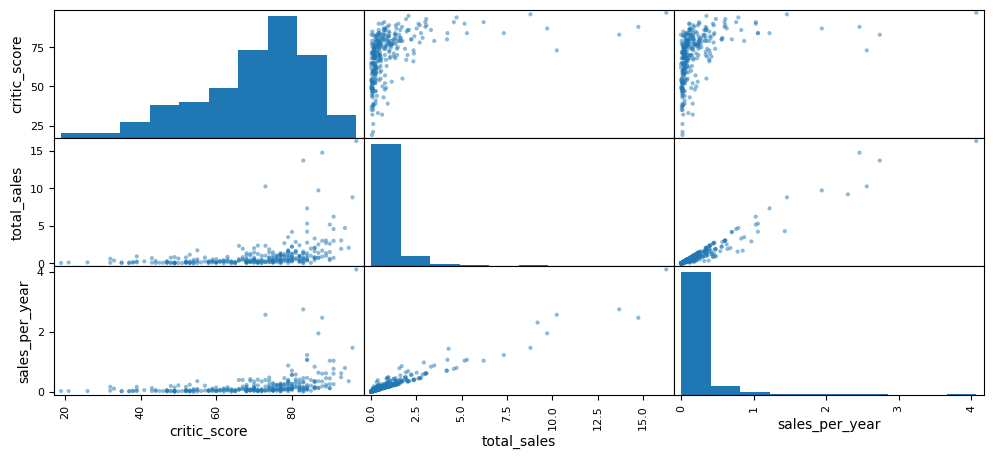

In [63]:
df_rd_x360 = df_recent_data.query('platform == "X360" and user_score!="tbd"')

#Matriz de dispersión
df_rd_x360.loc[:, 'user_score'] = df_rd_x360['user_score'].astype('float')
scat_matrix = pd.plotting.scatter_matrix(df_rd_x360.loc[:,['critic_score','user_score','total_sales','sales_per_year']]
            , figsize=(12, 5))

In [64]:
#Matriz de correlación de plataforma X360
df_rd_x360.loc[:,['critic_score','user_score','total_sales','sales_per_year']].corr()

,critic_score,user_score,total_sales,sales_per_year
critic_score,1.000000,0.568386,0.390005,0.373616
user_score,0.568386,1.000000,0.038918,-0.015324
total_sales,0.390005,0.038918,1.000000,0.968355
sales_per_year,0.373616,-0.015324,0.968355,1.000000


Para evaluar la existencia de una correlación entre las columnas `critic_score` y `total_sales` de la plataforma `X360`, se hace una prueba de correlación de Pearson y se obtiene el valor p correspondiente.
- Hipótesis nula (H₀): No existe correlación lineal entre las calificaciones de los críticos (critic_score) y las ventas totales de los juegos (total_sales).
- Hipótesis alternativa (H₁): Existe una correlación lineal entre las calificaciones de los críticos y las ventas totales de los juegos.

Se establece un nivel de significancia de α = 0.05 (5 %).

In [65]:
# Cálculo de correlación y significancia
r, p = st.pearsonr(df_rd_x360.query('critic_score.isna() == False')['critic_score'], 
                   df_rd_x360.query('critic_score.isna() == False')['total_sales'])

r = round(r,3)
print(f"Correlación Pearson: coeficiente = {r}, p-value ={p}")

alpha=0.05
if p < alpha: print("Se rechaza la hipótesis nula") 
else: print("No se rechaza la hipótesis nula")  

Correlación Pearson: coeficiente = 0.39, p-value =4.0545856466738945e-12
Se rechaza la hipótesis nula


El análisis proporciona evidencia estadísticamente significativa para afirmar que existe una correlación lineal positiva entre las calificaciones de los críticos (`critic_score`) y las ventas totales (`total_sales`) en la plataforma `X360`.

El coeficiente de 0.39 indica una correlación moderada, lo que sugiere que, en general, los juegos mejor calificados por los críticos tienden a registrar mayores ventas en esta plataforma.

No obstante, debe tomarse en cuenta que la columna `critic_score` contiene un alto porcentaje de valores ausentes, lo cual podría limitar la generalización del resultado.

#### Relación entre ventas y reseñas de la plataforma PS4
Se analiza cómo las reseñas de usuarios y profesionales afectan las ventas de la plataforma PS4.

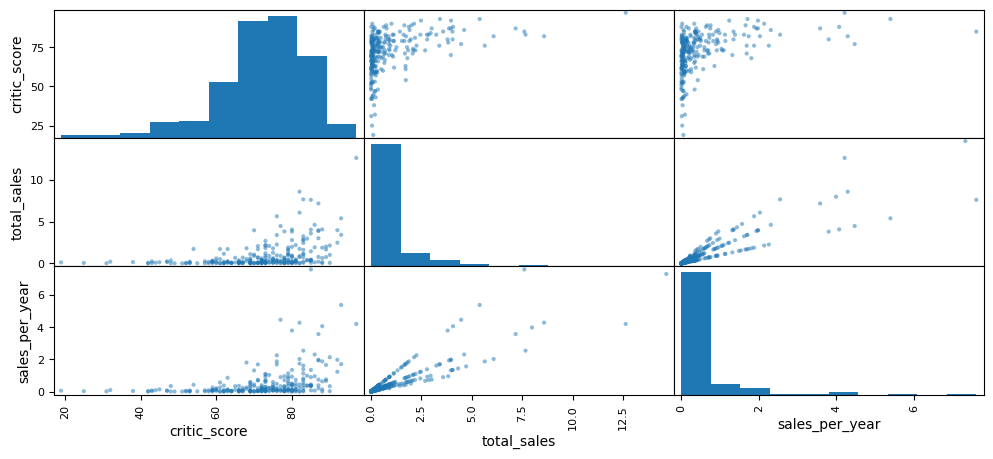

In [66]:
df_rd_ps4 = df_recent_data.query('platform == "PS4" and user_score!="tbd"')

#Matriz de dispersión
df_rd_ps4.loc[:, 'user_score'] = df_rd_ps4['user_score'] .astype('float')
scat_matrix = pd.plotting.scatter_matrix(df_rd_ps4.loc[:,['critic_score','user_score','total_sales','sales_per_year']]
            , figsize=(12, 5))

In [67]:
#Matriz de correlación de plataforma PS4
df_rd_ps4.loc[:,['critic_score','user_score','total_sales','sales_per_year']].corr()

,critic_score,user_score,total_sales,sales_per_year
critic_score,1.000000,0.557654,0.406469,0.387845
user_score,0.557654,1.000000,-0.031957,-0.039419
total_sales,0.406469,-0.031957,1.000000,0.893522
sales_per_year,0.387845,-0.039419,0.893522,1.000000


Para evaluar la existencia de una correlación entre las columnas `critic_score` y `total_sales` en la plataforma `PS4`, se aplica una prueba de correlación de Pearson y se obtiene el valor p correspondiente.
- Hipótesis nula (H₀): No existe correlación lineal entre las calificaciones de los críticos (critic_score) y las ventas totales de los juegos (total_sales).
- Hipótesis alternativa (H₁): Existe una correlación lineal entre las calificaciones de los críticos y las ventas totales de los juegos.

Se establece un nivel de significancia de α = 0.05 (5 %).

In [68]:
# Cálculo de correlación y significancia
r, p = st.pearsonr(df_rd_ps4.query('critic_score.isna() == False')['critic_score'], 
                   df_rd_ps4.query('critic_score.isna() == False')['total_sales']) 
r = round(r,3)
print(f"Correlación Pearson: coeficiente = {r}, p-value ={p}")

alpha=0.05
if p < alpha: print("Se rechaza la hipótesis nula") 
else: print("No se rechaza la hipótesis nula")  

Correlación Pearson: coeficiente = 0.406, p-value =2.3015406728060073e-11
Se rechaza la hipótesis nula


El análisis proporciona evidencia estadísticamente significativa para afirmar que existe una correlación lineal positiva entre las calificaciones de los críticos (`critic_score`) y las ventas totales (`total_sales`) en la plataforma `PS4`.

Se obtuvo un coeficiente de Pearson = 0.41, lo que indica una correlación moderada. Esto sugiere que, en general, los juegos mejor calificados por los críticos tienden a registrar mayores ventas en esta plataforma.

Al igual que en el caso de X360, este resultado debe interpretarse con precaución debido a la presencia de un alto porcentaje de valores ausentes en la columna `critic_score`.

#### Conclusión: Impacto de las reseñas en las ventas de videojuegos

Tomando en cuenta los datos de todas las plataformas, y en particular los resultados obtenidos para `X360` y `PS4`, se concluye que:
- Las calificaciones de los críticos (`critic_score`) muestran una correlación positiva y estadísticamente significativa con las ventas totales de los juegos.
- En contraste, las calificaciones de los usuarios (`user_score`) no presentan evidencia de correlación con las ventas, lo cual se observó de manera consistente en todas las plataformas analizadas.

No obstante, es importante considerar que tanto critic_score como user_score presentan un porcentaje elevado de valores ausentes (50.62 % y 39.52 %, respectivamente).

### Ventas del mismo juego en distintas plataformas
Se analizan las ventas del mismo juego en distintas plataformas.

In [69]:
#Vista previa de los juegos de la plataforma X360
df_rd_x360.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,sales_per_year
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27,4.07
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73,2.46
35,Call of Duty: Black Ops II,X360,2012,Shooter,8.25,4.24,0.07,1.12,83.0,4.8,M,13.68,2.74
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24,2.56
66,Halo 4,X360,2012,Shooter,6.65,2.28,0.04,0.74,87.0,7.0,M,9.71,1.94


In [70]:
#Vista previa de los juegos de la plataforma ps4
df_rd_ps4.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,sales_per_year
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,RP,14.63,7.32
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,4.21
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58,4.29
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,RP,7.98,3.99
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66,2.55


In [71]:
#Buscar juegos similares entre las plataformas
df_rd_x360[df_rd_x360.name.str.contains('Call of Duty')]['name'].value_counts()

name
Call of Duty: Modern Warfare 3    1
Call of Duty: Black Ops II        1
Call of Duty: Ghosts              1
Call of Duty: Advanced Warfare    1
Call of Duty: Black Ops 3         1
Name: count, dtype: int64

In [72]:
df_rd_ps4[df_rd_ps4.name.str.contains('Call of Duty')]['name'].value_counts()

name
Call of Duty: Black Ops 3         1
Call of Duty: Advanced Warfare    1
Call of Duty: Infinite Warfare    1
Call of Duty: Ghosts              1
Name: count, dtype: int64

Se detectaron dos juegos iguales que se usan en ambas plataformas:
- Call of Duty: Advanced Warfare
- Call of Duty: Ghosts

In [73]:
#Vista previa de juego "Call of Duty: Advanced Warfare"
df_recent_data.query('name == "Call of Duty: Advanced Warfare"')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,sales_per_year
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66,2.55
179,Call of Duty: Advanced Warfare,XOne,2014,Shooter,3.22,1.55,0.01,0.48,81.0,5.4,M,5.26,1.75
255,Call of Duty: Advanced Warfare,PS3,2014,Shooter,1.56,1.93,0.19,0.68,NaN,4.8,M,4.36,1.45
263,Call of Duty: Advanced Warfare,X360,2014,Shooter,2.77,1.11,0.00,0.40,NaN,4.9,M,4.28,1.43
4736,Call of Duty: Advanced Warfare,PC,2014,Shooter,0.15,0.23,0.00,0.03,78.0,4.5,M,0.41,0.14


In [74]:
#Vista previa de juego "Call of Duty: Ghosts"
df_recent_data.query('name == "Call of Duty: Ghosts"')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,sales_per_year
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24,2.56
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36,2.34
323,Call of Duty: Ghosts,PS4,2013,Shooter,1.78,1.43,0.05,0.57,78.0,3.7,M,3.83,0.96
493,Call of Duty: Ghosts,XOne,2013,Shooter,1.88,0.77,0.00,0.27,78.0,4.3,M,2.92,0.73
2916,Call of Duty: Ghosts,PC,2013,Shooter,0.23,0.41,0.00,0.05,NaN,NaN,RP,0.69,0.17
5348,Call of Duty: Ghosts,WiiU,2013,Shooter,0.22,0.09,0.01,0.03,69.0,3.4,M,0.35,0.09


Tomando como referencia el juego `Call of Duty: Advanced Warfare`, lanzado en el 2014,  las calificaciones de los profesionales más altas las tienen las plataformas `PS4` y `XOne`; asimismo, estas son las que tienen los más altos ingresos historicos y anuales.

Por el contrario, tomando como referencia el juego `Call of Duty: Ghosts`, lanzado en el 2013, las calificaciones de los profesionales más altas pertenecen a las plataformas `PS4` y `XOne`; sin embargo los ingresos historicos y anuales más altos pertenecen a `PS3` y `X360`. 

Esta diferencia podría deberse a que la plataforma `X360` se lanzó en el 2005 y la `XOne` en el 2013. A pesar de no tener una calificación significativamente alta, ha tendio más tiempo en el mercado por lo que ha tenido más tiempo para acumular ingresos totales. Cosa que podría suceder también con las plataformas `PS3` y  `PS4`.

### Ventas por género

Se examina la distribución general de las ventas de juegos por género.

In [75]:
#Cantidad de juegos por categoría (datos recientes)
df_recent_data['genre'].value_counts().sort_values(ascending=False)

genre
Action          1269
Role-Playing     465
Adventure        410
Sports           389
Misc             375
Shooter          329
Racing           180
Fighting         159
Simulation       136
Platform         122
Strategy         117
Puzzle            71
Name: count, dtype: int64

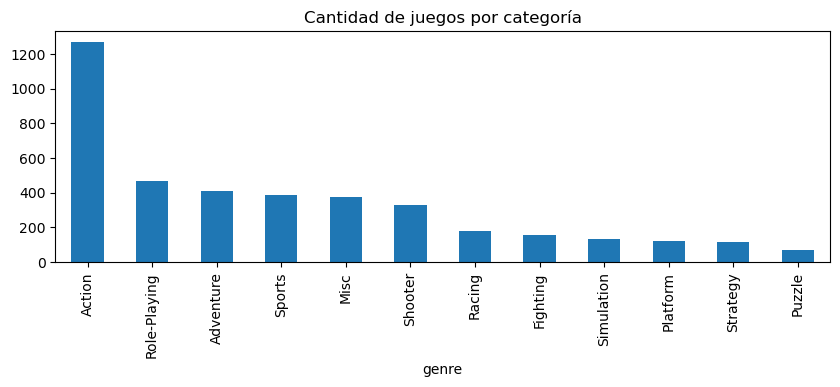

In [76]:
#Cantidad de juegos por categoría (datos recientes)
df_recent_data['genre'].value_counts().sort_values(ascending=False).plot(kind='bar',figsize=(10,3),
                                                                         title="Cantidad de juegos por categoría")
plt.show()

In [77]:
#Ingresos históricos por categoría por año
df_recent_data.groupby('genre')['sales_per_year'].sum().sort_values(ascending=False)

genre
Action          172.31
Shooter         139.89
Sports           84.71
Role-Playing     81.37
Misc             36.03
Racing           24.05
Platform         23.68
Fighting         21.06
Adventure        14.74
Simulation       13.91
Strategy          5.97
Puzzle            2.22
Name: sales_per_year, dtype: float64

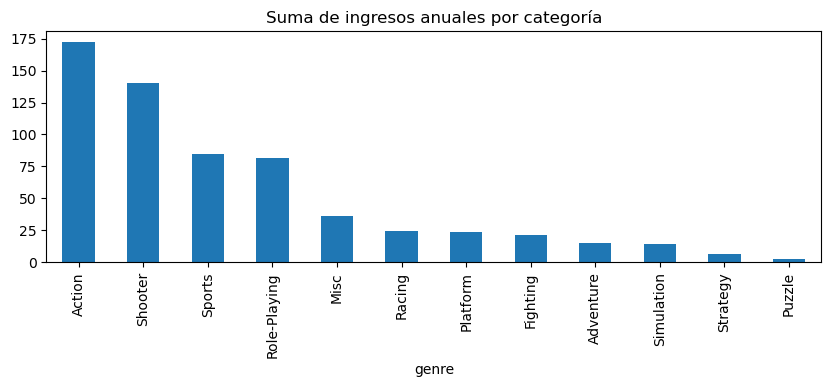

In [78]:
#Ingresos históricos por categoría por año
df_recent_data.groupby('genre')['sales_per_year'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(10,3),
                                                             title="Suma de ingresos anuales por categoría")
plt.show()

In [79]:
#Promedio de ingresos por año
df_recent_data.groupby('genre')['sales_per_year'].mean().sort_values(ascending=False)

genre
Shooter         0.425198
Sports          0.217763
Platform        0.194098
Role-Playing    0.174989
Action          0.135784
Racing          0.133611
Fighting        0.132453
Simulation      0.102279
Misc            0.096080
Strategy        0.051026
Adventure       0.035951
Puzzle          0.031268
Name: sales_per_year, dtype: float64

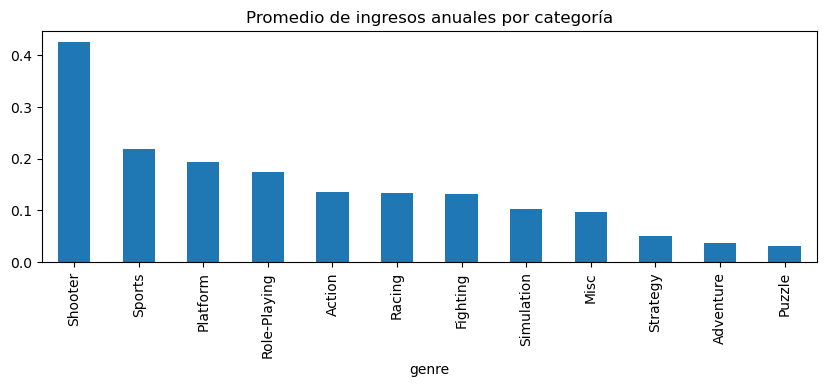

In [80]:
#Promedio de ingresos por año
df_recent_data.groupby('genre')['sales_per_year'].mean().sort_values(ascending=False).plot(
    kind='bar',figsize=(10,3),title="Promedio de ingresos anuales por categoría")
plt.show()

In [81]:
#Ingresos anuales máximos de cada categoría
df_recent_data.groupby('genre')['sales_per_year'].max().sort_values(ascending=False)

genre
Sports          7.60
Shooter         7.32
Role-Playing    7.14
Action          5.26
Fighting        2.52
Racing          2.36
Misc            2.30
Platform        1.98
Simulation      1.83
Adventure       0.94
Strategy        0.42
Puzzle          0.40
Name: sales_per_year, dtype: float64

Historicamente, el género de acción es el que tiene mayor número de juegos y mayores ingresos totales y por año. 

Al checar el promedio de ingresos por año y por juego, los juegos de mayor promedio son los de tiro, los cuales representan más del doble de los ingresos de los de acción. Cabe mencionar que la cantidad de juegos de tiro son la mitad de los de acción, cosa que explicaria por qué los ingresos históricos de los de acción son más altos.

Analizando los ingresos anuales máximos, los géneros que han tenido los mayores ingresos anuales son deportes, de tiro y los de rol, seguidos por los de acción; cuyos ingresos totales aumentan al haber más juegos de este tipo.

Los juegos de categorías de rompecabezas, aventura y estrategia, son los de menores ingresos históricos asi como en los promedios anuales.

### Ventas por clasificación

Se examina la distribución general de las ventas de juegos por su clasificación ESRB. 

La columna rating cuenta con los siquientes valores:
- E (todos)
- EC (mayores de 3 años)
- E10+ (mayores de 10 años)
- K-A (mayores de 10 años) dejó de usarse en 1998 y se reemplazó con E10+
- T (mayores de 13 años)
- M (mayores de 17 años)
- AO (sólo para adultos de 18 años en adelante)
- RP (pendiente de clasificar)

In [82]:
#Cantidad de juegos por clasificación (datos recientes)
df_recent_data['rating'].value_counts().sort_values(ascending=False)

rating
RP      1709
M        622
E        618
T        616
E10+     456
EC         1
Name: count, dtype: int64

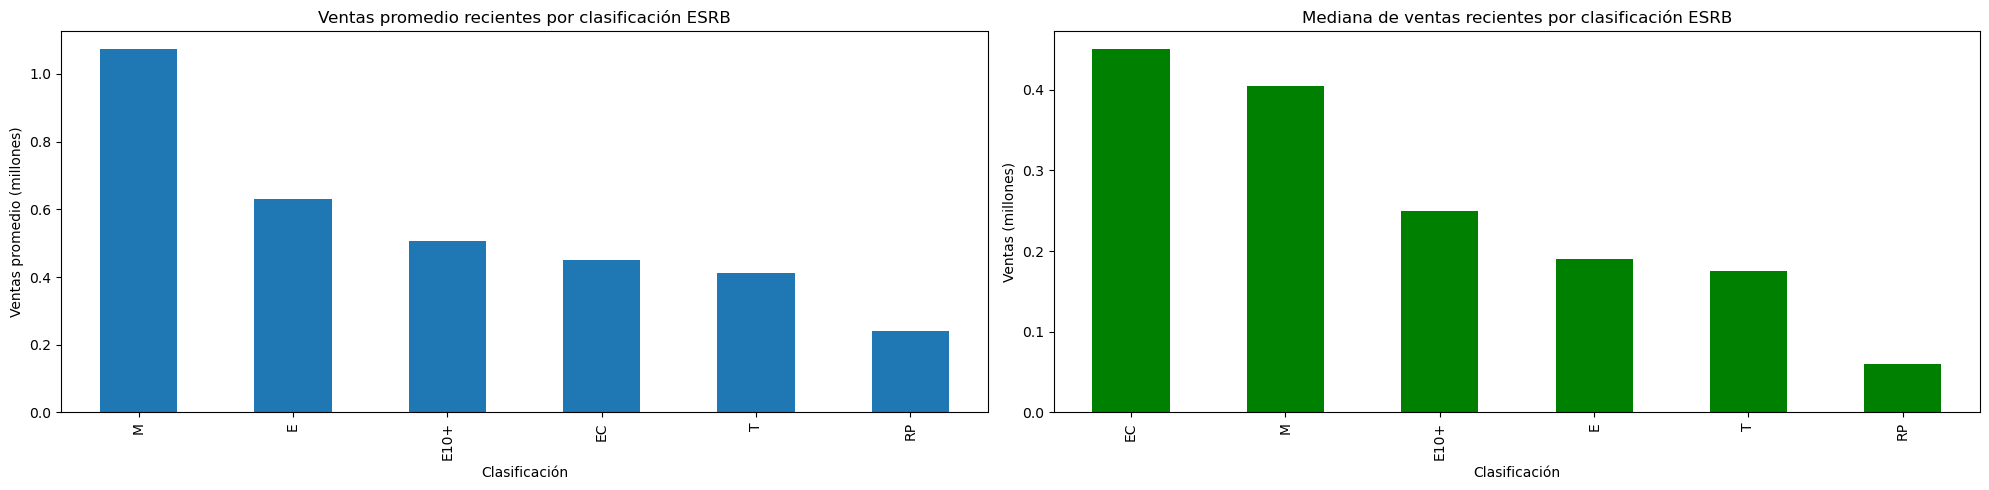

In [83]:
#Importante: no se ven subplots en el curso
# Crear la figura y los subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Media de ventas por clasificación
df_recent_data.groupby('rating')['total_sales'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Ventas promedio recientes por clasificación ESRB')
axes[0].set_ylabel('Ventas promedio (millones)')
axes[0].set_xlabel('Clasificación')

# Mediana de ventas por clasificación
df_recent_data.groupby('rating')['total_sales'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Mediana de ventas recientes por clasificación ESRB')
axes[1].set_ylabel('Ventas (millones)')
axes[1].set_xlabel('Clasificación')

plt.tight_layout()
plt.show()



En los últimos años, en promedio la categoría con mayores ingresos es la de `M` (mayores de 17 años), seguida por la `E` (todos).

Sin embargo, al ver las medianas, la de mayor es `EC` (mayores de 3 años) seguida por `M`.

## Perfil de usuario por región
A continuación, se analizan las diferencias entre regiones determinando:
- las cinco plataformas principales por región
- los cinco géneros principales
- las ventas en base a las clasificaciones de ESRB
- las variaciones en sus cuotas de mercado de una región a otra

### Región NA (Norteamérica)
#### plataformas principales

Se buscan las cinco plataformas principales de la región NA.

In [84]:
#plataformas principales - suma de ingresos historicos
print('5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:')
df_recent_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)

5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:


platform
X360    226.80
PS3     168.26
PS4     108.74
XOne     93.12
3DS      82.65
Name: na_sales, dtype: float64

In [85]:
for plat in ['X360','PS3','PS4','XOne','3DS']:
    print('year of release of the first game released in the platform',plat,':'
          ,df.query('platform == @plat')['year_of_release'].min())

year of release of the first game released in the platform X360 : 2005
year of release of the first game released in the platform PS3 : 2006
year of release of the first game released in the platform PS4 : 2013
year of release of the first game released in the platform XOne : 2013
year of release of the first game released in the platform 3DS : 2011


La plataforma `X360` es la de mayores ingresos, tomando en cuenta datos recientes, pero también es la que más tiempo tiene en el mercado, el orden de la suma de los ingresos actua acorde al año de lanzamiento de la plataforma a excepción de la `3DS`.

#### géneros principales
Se buscan los cinco géneros principales de la región NA.

In [86]:
#plataformas principales - suma de ingresos historicos
print('5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:')
df_recent_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)

5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:


platform
X360    226.80
PS3     168.26
PS4     108.74
XOne     93.12
3DS      82.65
Name: na_sales, dtype: float64

In [87]:
#Géneros principales - promedio de ingresos historicos
print('5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:')
df_recent_data.groupby('genre')['na_sales'].mean().sort_values(ascending=False).head(5)

5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:


genre
Shooter     0.590973
Platform    0.313770
Sports      0.279434
Fighting    0.198931
Misc        0.185840
Name: na_sales, dtype: float64

Al igual que las ventas por género globales, el género principal de la región NA es `Shooter`. También coinciden los generos `platform` y `Sports` en los primeros 5 pero en distinto orden.

#### Ventas en base a la clasificacion ESRB
Se analiza si las clasificaciones ESRB afectan las ventas de la region NA.

Al igual que en el análisis de clasificación ESRB global, no se toma en cuenta la clasificación `AO` ni `K-A`.

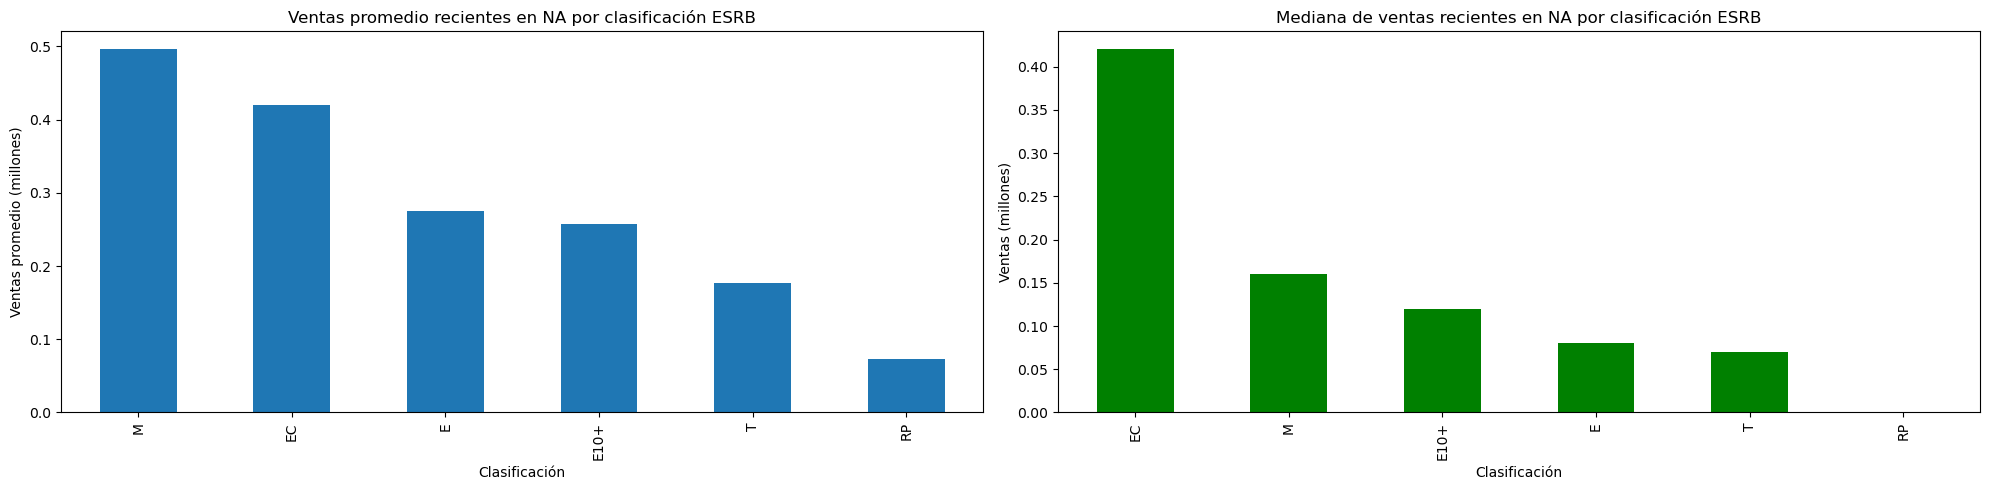

In [88]:
#Importante: no se ven subplots en el curso
#Ingresos recientes de juegos por año clasificación sin AO ni K-A

# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

df_recent_data.groupby('rating')['na_sales'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Ventas promedio recientes en NA por clasificación ESRB')
axes[0].set_ylabel('Ventas promedio (millones)')
axes[0].set_xlabel('Clasificación')

# Verde armónico: #2ca02c
df_recent_data.groupby('rating')['na_sales'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Mediana de ventas recientes en NA por clasificación ESRB')
axes[1].set_ylabel('Ventas (millones)')
axes[1].set_xlabel('Clasificación')

plt.tight_layout()
plt.show()


Al igual que en el análisis global, en promedio la clasificación `M` (mayores de 17 años) es la de mayor ingresos y al ver las medianas, la más alta es de la clasificación `EC` (mayores de 3 años).

Al observar las medianas restantes, no tienen una diferencia significativa entre ellas a excepción de `RP`, cuyo valor es 0.

### Región EU (Europa)
#### plataformas principales

Se buscan las cinco plataformas principales de la región EU.

In [89]:
#plataformas principales - suma de ingresos historicos
print('5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:')
df_recent_data.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)

5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:


platform
PS3     163.10
PS4     141.09
X360    117.10
3DS      61.27
PC       56.70
Name: eu_sales, dtype: float64

In [90]:
for plat in ['PS3','PS4','X360','3DS','PC']:
    print('year of release of the first game released in the platform',plat,':'
          ,df.query('platform == @plat')['year_of_release'].min())

year of release of the first game released in the platform PS3 : 2006
year of release of the first game released in the platform PS4 : 2013
year of release of the first game released in the platform X360 : 2005
year of release of the first game released in the platform 3DS : 2011
year of release of the first game released in the platform PC : 1985


Las plataformas `PS3` y `PS4` son las de mayores ingresos en esta región si embargo, la `PS4` tiene menos años en el mercado por lo que en un futuro podría tener más ingresos que su predecesora. 

Los juegos de `PC` aparecen en los primeros 5 de esta región, algo interesante. Este tipo de plataforma se remonta a 1985 sin embargo hay de muchos tipos y marcas y esta en constante actualización.

#### géneros principales
Se buscan los cinco géneros principales de la región EU.

In [91]:
#Géneros principales - promedio de ingresos historicos
print('5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:')
df_recent_data.groupby('genre')['eu_sales'].mean().sort_values(ascending=False).head(5)

5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:


genre
Shooter     0.449909
Platform    0.246475
Sports      0.227455
Racing      0.225444
Action      0.156911
Name: eu_sales, dtype: float64

Nuevamente, el género principal es `Shooter`. Los géneros que coinciden en est región con el análisis global son `Platform`, `Sports` y `Action`. El género `Racing` es el único que no entro en los primeros 5 globales pero esta en el puesto 6 global.

#### Ventas en base a la clasificacion ESRB
Se analiza si las clasificaciones ESRB afectan las ventas de la region EU.

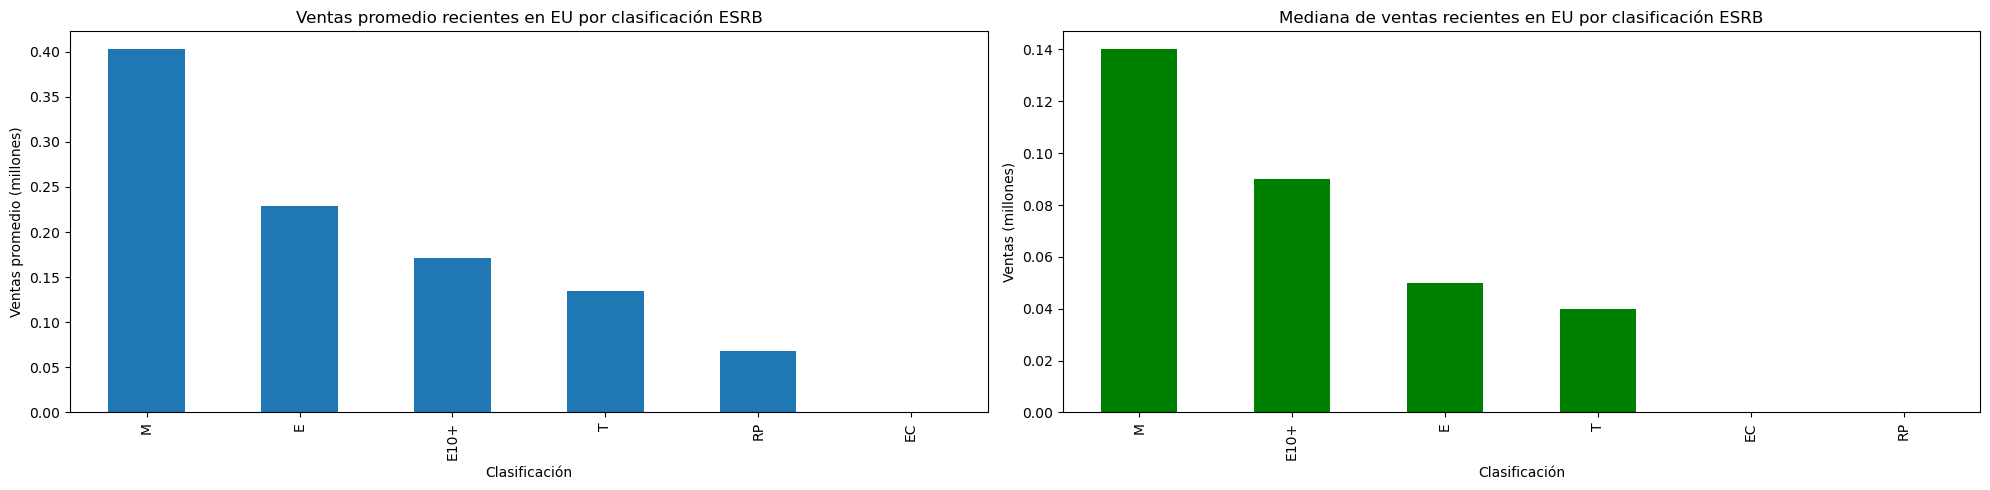

In [92]:
# Crear figura y subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

df_recent_data.groupby('rating')['eu_sales'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Ventas promedio recientes en EU por clasificación ESRB')
axes[0].set_ylabel('Ventas promedio (millones)')
axes[0].set_xlabel('Clasificación')

df_recent_data.groupby('rating')['eu_sales'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Mediana de ventas recientes en EU por clasificación ESRB')
axes[1].set_ylabel('Ventas (millones)')
axes[1].set_xlabel('Clasificación')

plt.tight_layout()
plt.show()


Al igual que en el análisis global, en promedio la clasificación `M` (mayores de 17 años) es la de mayor ingresos.


Asimismo, la mediana mayor es la de la clasificación `M`. El resto de las clasificaciones muestran una diferencia significativa con la clasificación de mayor ingreso.

### Región JP (Japón)


#### plataformas principales
Se buscan las cinco plataformas principales de la región JP.

In [93]:
#plataformas principales - promedio de ingresos historicos
print('5 Plataformas principales, de años recientes, con mayor promedio de ingresos históricos:')
df_recent_data.groupby('platform')['jp_sales'].mean().sort_values(ascending=False).head(5)

5 Plataformas principales, de años recientes, con mayor promedio de ingresos históricos:


platform
3DS     0.196523
WiiU    0.088503
PSP     0.077051
PS3     0.069760
PSV     0.050909
Name: jp_sales, dtype: float64

In [94]:
#plataformas principales - suma de ingresos historicos
print('5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:')
df_recent_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

5 Plataformas principales, de años recientes, con mayor suma de ingresos históricos:


platform
3DS    100.62
PS3     49.39
PSP     24.04
PSV     21.84
PS4     15.96
Name: jp_sales, dtype: float64

Al analizar las plataformas principales de la región `JP` se observa que las principales, con la suma de ingresos mayores, pertenecen a la familia de Sony (`PS`s) a excepción de la `3DS`.

#### géneros principales
Se buscan los cinco géneros principales de la región JP.

In [95]:
#Géneros principales - promedio de ingresos historicos
print('5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:')
df_recent_data.groupby('genre')['jp_sales'].mean().sort_values(ascending=False).head(5)

5 géneros principales, de años recientes, con mayor promedio de ingresos históricos:


genre
Role-Playing    0.171763
Platform        0.099426
Simulation      0.085588
Fighting        0.077862
Action          0.050134
Name: jp_sales, dtype: float64

In [96]:
#Géneros principales - promedio de ingresos historicos
print('géneros de años recientes, con menor promedio de ingresos históricos:')
df_recent_data.groupby('genre')['jp_sales'].mean().sort_values(ascending=False).tail(4)

géneros de años recientes, con menor promedio de ingresos históricos:


genre
Shooter      0.036231
Racing       0.031333
Adventure    0.029439
Sports       0.028509
Name: jp_sales, dtype: float64

A diferencia de las otras dos regiones, en Jápón el género principal es `Role-Playing` y el género `Shooter` esta entre los últimos. Los principales géneros de esta región que coinciden con los globales son el ya mencionado `Role-Playing`, `Action` y `Platform`. 

#### Ventas en base a la clasificacion ESRB
Se analiza si las clasificaciones ESRB afectan las ventas de la region JP.

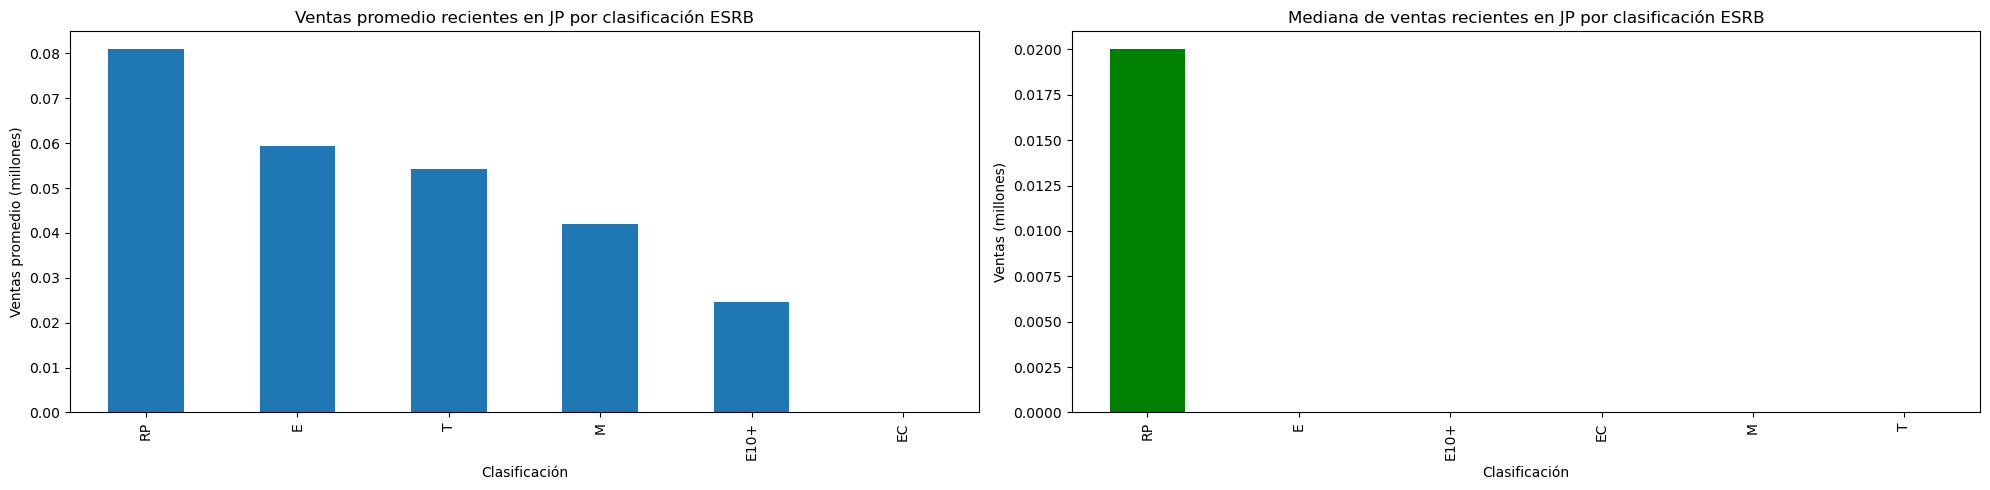

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

df_recent_data.groupby('rating')['jp_sales'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Ventas promedio recientes en JP por clasificación ESRB')
axes[0].set_ylabel('Ventas promedio (millones)')
axes[0].set_xlabel('Clasificación')

df_recent_data.groupby('rating')['jp_sales'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='green')
axes[1].set_title('Mediana de ventas recientes en JP por clasificación ESRB')
axes[1].set_ylabel('Ventas (millones)')
axes[1].set_xlabel('Clasificación')

plt.tight_layout()
plt.show()



A diferencia de las otras regiones, la clasificación principal de Japón es `RP` (pendiente de clasificar).

Asimismo, al evaluar las medianas todas se ubican en ceros a excepción de `RP`.

### Cuota de mercado entre regiónes

In [98]:
#plataformas principales recientes
df_recent_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(3)

platform
PS3     445.57
X360    380.38
PS4     314.14
Name: total_sales, dtype: float64

Las plataformas principales con mayor suma de ingresos históricos son:
- PS3 
- X360
- PS4

La plataforma `x360`, que esta entre las plataformas más rentables, esta entre las principales de las regiones `NA` y `EU` pero no de `JP`. 

In [99]:
#Ingresos totales recientes
total_income = df_recent_data['total_sales'].sum()

#Ingresos por plataforma de los últimos 10 años
df_recent_data_ps3 = df_recent_data.query('platform == "PS3"')
df_recent_data_x360 = df_recent_data.query('platform == "X360"')
df_recent_data_ps4 = df_recent_data.query('platform == "PS4"')

#variaciones en sus cuotas de mercado de una región a otra de plataforma PS3
print('Variación en cuota de mercado entre regiónes de la plataforma PS3')
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(region,  round(df_recent_data_ps3[region].sum() /total_income*100,3)  ,'%')

Variación en cuota de mercado entre regiónes de la plataforma PS3
na_sales 8.611 %
eu_sales 8.347 %
jp_sales 2.527 %


In [100]:
#variaciones en sus cuotas de mercado de una región a otra de plataforma X360
print('Variación en cuota de mercado entre regiónes de la plataforma X360')
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(region,  round(df_recent_data_x360[region].sum() /total_income*100,3)  ,'%')

Variación en cuota de mercado entre regiónes de la plataforma X360
na_sales 11.606 %
eu_sales 5.992 %
jp_sales 0.171 %


In [101]:
#variaciones en sus cuotas de mercado de una región a otra de plataforma PS4
print('Variación en cuota de mercado entre regiónes de la plataforma PS4')
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(region,  round(df_recent_data_ps4[region].sum() /total_income*100,3)  ,'%')

Variación en cuota de mercado entre regiónes de la plataforma PS4
na_sales 5.565 %
eu_sales 7.22 %
jp_sales 0.817 %


Al analizar las cuotas de mercado de las plataformas principales por region se observa que:
- en general, la región `NA` tiene las cuotas más altas, seguida de la región `EU`, dejando al final a la `JP`
- la cuota más alta es de los ingresos de la región `NA` con la plataforma `X360`
- la cuota más baja es de los ingresos de la región `JP` con la plataforma `X360`

Cabe mencionar que las plataformas principales de la región `JP` son las `PS`s y aún asi, estas tienen cuotas bajas en está región.

## Pruebas de hipótesis

A continuación, se ponen a prueba las siguientes hipótesis:
- Las calificaciones promedio otorgadas por los usuarios son iguales entre las plataformas Xbox One y PC.
- Las calificaciones promedio otorgadas por los usuarios difieren entre los géneros Acción y Deportes.

### hipótesis de calificaciones promedio para Xbox One y PC
Antes de comparar las calificaciones promedio de los usuarios entre las plataformas Xbox One y PC, se verifica si las distribuciones de ambas muestras siguen una distribución normal con la prueba de normalidad (Shapiro-Wilk)

**Prueba de normalidad**

- Hipótesis nula (H₀): Los datos siguen una distribución normal.
- Hipótesis alternativa (H₁): Los datos no siguen una distribución normal.

Se establece un nivel de significancia α = 0.05.

In [102]:
#comprobación de distribución normal
user_score_xo = df_recent_data.query(
'platform == "XOne" and user_score != "tbd" and user_score.isna() == False'
                                                                    )['user_score'].astype('float')
user_score_pc = df_recent_data.query(
    'platform == "PC" and user_score != "tbd" and user_score.isna() == False'
                                                                    )['user_score'].astype('float')

alpha = 0.05 #nivel de significancia estadística crítica

# Normalidad de los residuos Shapiro-Wilk test Xone
shapiro_test = st.shapiro(user_score_xo)
print('Variable user_score de plataforma XOne:')
print(shapiro_test)

if shapiro_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")
print()

# Normalidad de los residuos Shapiro-Wilk test PC
shapiro_test = st.shapiro(user_score_pc)
print('Variable user_score de plataforma PC:')
print(shapiro_test)

if shapiro_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")

Variable user_score de plataforma XOne:
ShapiroResult(statistic=0.9550558360108363, pvalue=1.525044361110726e-05)
Se rechaza la hipótesis nula

Variable user_score de plataforma PC:
ShapiroResult(statistic=0.9421177319548403, pvalue=1.3281758846340373e-09)
Se rechaza la hipótesis nula


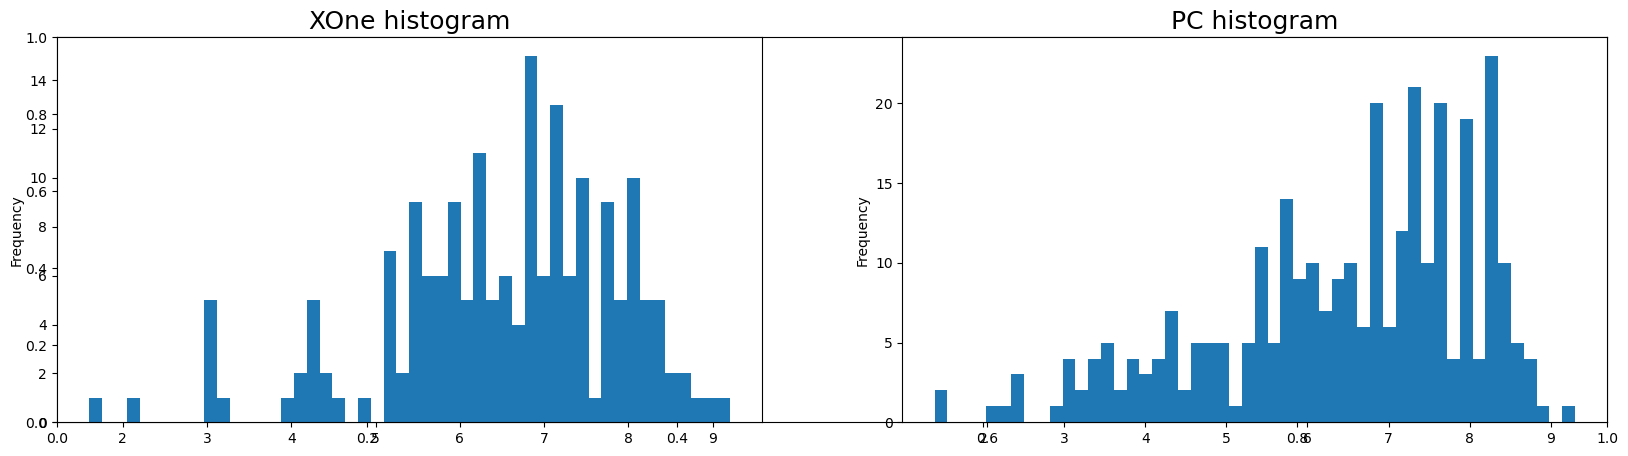

In [103]:
#Graficar datos
plt.subplots(figsize=(20, 5)) 
user_score_xo.plot(kind='hist', ax= plt.subplot(1,2,1),bins=50)
plt.title('XOne histogram',fontsize = 18)

user_score_pc.plot(kind='hist', ax= plt.subplot(1,2,2),bins=50)
plt.title('PC histogram',fontsize = 18)
plt.show()

In [104]:
# Cantidad de datos en user_score para Xbox One y PC
print(f'Tamaño de muestra para Xbox One: {user_score_xo.dropna().shape[0]}')
print(f'Tamaño de muestra para PC: {user_score_pc.dropna().shape[0]}')

Tamaño de muestra para Xbox One: 182
Tamaño de muestra para PC: 307


Las muestras son bastante grandes, 182 datos para Xbox One y 307 para PC, por lo que podemos confiar en que el test t de Welch es válido, aunque las calificaciones no sigan una distribución normal.

En otras palabras, el tamaño de los datos es suficiente para usar esta prueba y comparar los promedios de las dos plataformas sin problema.

**Prueba de igualdad de varianzas (Levene)**

Se evalúa si las varianzas de ambas muestras son iguales.
- Hipótesis nula (H₀): Las varianzas de las dos muestras son iguales.
- Hipótesis alternativa (H₁): Las varianzas de las dos muestras son diferentes.

In [105]:
#Varianza de las muestras - prueba de levene
levene_test = st.levene (user_score_xo, user_score_pc, center = 'median') 
print('Prueba de varianzas iguales:')
print(levene_test)

if levene_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")
print()

Prueba de varianzas iguales:
LeveneResult(statistic=5.516327585628806, pvalue=0.019238606822499546)
Se rechaza la hipótesis nula



**Prueba de hipótesis: Comparación de medias**
Dado que las distribuciones no son normales y las varianzas son distintas, se aplica un t-test para muestras independientes con varianzas desiguales (Welch’s t-test).
- Hipótesis nula (H₀): Las calificaciones promedio de los usuarios en Xbox One y PC son iguales.
- Hipótesis alternativa (H₁): Las calificaciones promedio de los usuarios en Xbox One y PC son diferentes.

Se mantiene α = 0.05.

In [106]:
#si el valor p es menor que alfa, se rechaza la hipótesis
results = st.ttest_ind(user_score_xo, user_score_pc,equal_var=False)
print('p-value: ', results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula") 

p-value:  0.6130712247638477
No se rechaza la hipótesis nula


**Conclusión: Impacto de la plataforma en las calificaciones de los usuarios**

No se rechaza la hipótesis nula, por lo tanto, no se tiene evidencia suficiente para afirmar que las calificaciones promedio otorgadas por los usuarios en las plataformas Xbox One y PC son diferentes. Aunque existen diferencias en la distribución y varianza de los datos, los promedios no muestran una diferencia estadísticamente significativa.

### Hipótesis de calificaciones promedio para los géneros acción y deportes

Primero, se verifica si la distribución de las calificaciones (user_score) para ambos géneros es normal.
- Hipótesis nula (H₀): Los datos siguen una distribución normal.
- Hipótesis alternativa (H₁): Los datos no siguen una distribución normal.

Se establece un nivel de significancia α = 0.05.

In [107]:
#comprobación de distribución normal
user_score_ac = df_recent_data.query(
    'genre == "Action" and user_score != "tbd" and user_score.isna() == False'
                                                                        )['user_score'].astype('float')
user_score_dp = df_recent_data.query(
    'genre == "Sports" and user_score != "tbd" and user_score.isna() == False'
                                                                        )['user_score'].astype('float')

# Normalidad de los residuos Shapiro-Wilk test Xone
shapiro_test = st.shapiro(user_score_ac)
print('Variable user_score del género acción:')
print(shapiro_test)

if shapiro_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")
print()

# Normalidad de los residuos Shapiro-Wilk test PC
shapiro_test = st.shapiro(user_score_dp)
print('Variable user_score del género deportes:')
print(shapiro_test)

if shapiro_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")

Variable user_score del género acción:
ShapiroResult(statistic=0.931012589018936, pvalue=6.259405821059731e-17)
Se rechaza la hipótesis nula

Variable user_score del género deportes:
ShapiroResult(statistic=0.9578668686586036, pvalue=1.33556592583232e-06)
Se rechaza la hipótesis nula


In [108]:
print(f'Tamaño muestra Acción: {user_score_ac.dropna().shape[0]}')
print(f'Tamaño muestra Deportes: {user_score_dp.dropna().shape[0]}')


Tamaño muestra Acción: 664
Tamaño muestra Deportes: 246


Los resultados indican que ambas muestras no siguen una distribución normal. Sin embargo, dado que el tamaño de las muestras es grande, 664 para Acción y 246 para Deportes, el uso del test t es apropiado y confiable a pesar de la falta de normalidad.

In [109]:
#Varianza de las muestras - prueba de levene
levene_test = st.levene (user_score_ac, user_score_dp, center = 'median') 
print('Prueba de varianzas iguales:')
print(levene_test)

if levene_test[1] < alpha: print("Se rechaza la hipótesis nula")
else: print("No se rechaza la hipótesis nula")
print()

Prueba de varianzas iguales:
LeveneResult(statistic=18.398485636804207, pvalue=1.9840382117903915e-05)
Se rechaza la hipótesis nula



**Prueba de hipótesis para comparar calificaciones promedio**

A pesar de la falta de normalidad, se procede a aplicar un t-test para varianzas distintas (Welch’s t-test) para comparar las medias de ambos géneros.
- Hipótesis nula (H₀): Las calificaciones promedio de los géneros Acción y Deportes son iguales.
- Hipótesis alternativa (H₁): Las calificaciones promedio de los géneros Acción y Deportes son diferentes.

Se mantiene α = 0.05.

In [110]:
#si el valor p es menor que alfa, se rechaza la hipótesis
results = st.ttest_ind(user_score_ac, user_score_dp,equal_var=False)
print('p-value: ', results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula") 

p-value:  8.285648549432564e-19
Se rechaza la hipótesis nula


No existe evidencia para afirmar que las calificaciones promedio de los usuarios de los géneros Acción y Deportes sean iguales; es decir, las calificaciones promedio difieren significativamente entre estos dos géneros.

## Conclusión

### Información analizada

Se partió de un conjunto de datos con 16,715 registros, sobre los cuales se realizaron las siguientes acciones:
- En las columnas `name` y `genre` había menos del 1% de valores ausentes, y en `year_of_release` un 1.61%. Debido a que estos porcentajes son bajos, se eliminaron dichas filas.
- En `critic_score` había un 50.62% de valores ausentes y en `user_score` un 39.52%. Estos altos porcentajes impidieron eliminar esas filas o imputar valores sin afectar el análisis, por lo que se mantuvieron sin cambios.
- En la columna `rating` había un 39.94% de valores ausentes, los cuales fueron asignados a la categoría RP (Rating Pending).

Se crearon columnas adicionales para facilitar el análisis:
- `total_sales`: representa las ventas totales por videojuego.
- `sales_per_year`: representa las ventas anuales promedio por juego.

---

### Conclusiones globales

Se identificaron patrones relevantes para entender qué factores influyen en el éxito de un videojuego:
- El año de lanzamiento de un juego no influye directamente en sus ventas, pero sí la cantidad total de juegos lanzados ese año, ya que una mayor variedad baja los ingresos por juego.
- El año de lanzamiento de la plataforma tiene cierta influencia, aunque no es determinante; plataformas exitosas suelen renovar versiones cada aproximadamente 6 años, pero las anteriores continúan generando ingresos.
  - Las plataformas con mayores ingresos recientes son: PS2, X360, PS3, Wii y DS.
  
- Las calificaciones otorgadas por profesionales (critic_score) influyen positivamente en las ventas, mientras que las calificaciones de los usuarios (user_score) no muestran relación significativa con los ingresos.
  - Cabe señalar que ambas columnas presentan un alto porcentaje de valores ausentes, por lo que esta conclusión no se puede generalizar.
- El género del juego impacta en los ingresos:
  - Acción es el género con mayor número de juegos y mayores ingresos históricos.
  - Tiro es el género con mayor promedio de ingresos. Para aumentar ingresos totales en esta categoría, sería útil incrementar la cantidad de juegos lanzados por año.
  - Las categorías con mayores ingresos son: tiro, juegos de rol, acción y deportes.
  - Las categorías con menores ingresos son: rompecabezas, aventura y estrategia.
- La clasificación ESRB con mayores ingresos históricos es `M` (mayores de 17 años).

---

### Conclusiones por región

**Norteamérica (NA):**
- Plataformas con mayores ingresos promedio: X360, PS3, PS4, XOne y 3DS.
- Géneros con mayores ingresos promedio: Shooter, Platform, Sports, Racing y Action.
- La clasificación ESRB con mayor ingreso promedio es M, mientras que la mediana más alta corresponde a EC (mayores de 3 años).
- La mediana de ingresos para la categoría RP es 0 y el resto de medianas no difiere significativamente entre sí.

**Europa (EU):**
- Plataformas con mayores ingresos: PS3, PS4, X360, 3DS y PC.
- Géneros con mayores ingresos: Shooter, Platform, Sports, Racing y Action.
- La clasificación ESRB con mayores ingresos promedio y mediana es M, siendo significativamente superior al resto.

**Japón (JP):**
- Plataformas con mayores ingresos: 3DS, WiiU, PSP, PS3 y PSV.
- Géneros con mayores ingresos: Role-Playing, Platform, Simulation, Fighting y Action.
- El género Shooter, dominante en otras regiones, está entre los menos rentables aquí.
- La clasificación ESRB con mayor ingreso promedio es RP.
- La mediana de ingresos para todas las clasificaciones, excepto RP, es cero.